# Waverity ML Engineering — Crack Detection

## Table of Contents

1. **Data Visualization & Analysis**
   1.1 Dataset overview and class imbalance analysis
   1.2 Sample image/mask pairs

2. **CNN (U-Net) for Crack Segmentation**
   2.1 TensorFlow / GPU configuration & data pipeline
   2.2 U-Net architecture
   2.3 Loss function and metrics
   2.4 Model compilation
   2.5 Model training
   2.6 Training curves
   2.7 Model evaluation on test set (naive)
   2.8 Saving final artifacts
   2.9 Corrected evaluation — handling crack-free images
   2.10 False positive analysis
   2.11 Room for improvement
   — Section 2 Summary

4. **Mathematical Description of Cracks via Regression**
   3.1 Fitting the raw mask
   3.2 Fitting the skeletonized mask
   3.3 Fitting the main branch (longest path)
   3.4 Testing higher-degree polynomials
   — Section 3 Summary & Interpretation

5. **Synthetic Binary Crack Images**
   4.1 Generating the 10 synthetic images
   — Section 4 Summary

6. **Inverse Problem — Fitting Functions to Synthetic Images**
   5.1 Fitting all 10 synthetic images
   5.2 Multi-component detection: applying Hough Transform principles
   5.3 Improving multi-sine separation with RANSAC
   — Section 5 Summary & Interpretation

## 0. Environment Setup

In [1]:
!pip install -q opencv-python-headless scikit-image scipy pandas

### Dataset paths

In [2]:
import os
DATA_DIR = "Conglomerate Concrete Crack Detection"

TRAIN_IMG_DIR = os.path.join(DATA_DIR, "Train", "images")
TRAIN_MASK_DIR = os.path.join(DATA_DIR, "Train", "masks")
TEST_IMG_DIR = os.path.join(DATA_DIR, "Test", "images")
TEST_MASK_DIR = os.path.join(DATA_DIR, "Test", "masks")

### Fix NumPy version for TensorFlow-DirectML compatibility

In [3]:
!pip install "numpy==1.23.5" --force-reinstall --no-deps

  Using cached numpy-1.23.5-cp310-cp310-win_amd64.whl.metadata (2.3 kB)
Using cached numpy-1.23.5-cp310-cp310-win_amd64.whl (14.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6


### Core imports

In [4]:
import os
import glob
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd

### Output directory setup

In [5]:
OUTPUT_DIR = os.path.join(os.getcwd(), "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "synthetic"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "inverse_fit"), exist_ok=True)

print("OUTPUT_DIR is ready:", OUTPUT_DIR)

OUTPUT_DIR is ready: C:\Users\pikie\Downloads\Conglomerate Concrete Crack Detection\outputs


### Dataset analysis

Computes pair count, image sizes, and crack pixel ratio (class imbalance check).
Displays sample image/mask pairs and the crack ratio distribution across the dataset.

In [6]:
def list_pairs(img_dir, mask_dir):
    """Returns the list of image/mask pairs (matched by identical filename)."""
    img_files = sorted(glob.glob(os.path.join(img_dir, "*.*")))
    pairs = []
    for img_path in img_files:
        fname = os.path.basename(img_path)
        mask_path = os.path.join(mask_dir, fname)
        if os.path.exists(mask_path):
            pairs.append((img_path, mask_path))
        else:
            # sometimes the mask may have a different extension (.png vs .jpg)
            base = os.path.splitext(fname)[0]
            candidates = glob.glob(os.path.join(mask_dir, base + ".*"))
            if candidates:
                pairs.append((img_path, candidates[0]))
    return pairs


def analyze_dataset(pairs, split_name):
    print(f"\n{'='*50}")
    print(f"{split_name} dataset")
    print(f"{'='*50}")
    print(f"Number of pairs: {len(pairs)}")

    if len(pairs) == 0:
        print("WARNING: No pairs found. Check the folder paths.")
        return None

    sizes = []
    crack_ratios = []

    for img_path, mask_path in pairs:
        img = cv2.imread(img_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if img is None or mask is None:
            print(f"  Could not read: {img_path}")
            continue

        sizes.append(img.shape[:2])

        # binary mask assumed: >127 = crack
        binary_mask = (mask > 127).astype(np.uint8)
        crack_ratio = binary_mask.sum() / binary_mask.size
        crack_ratios.append(crack_ratio)

    sizes = np.array(sizes)
    crack_ratios = np.array(crack_ratios)

    print(f"\nImage sizes:")
    print(f"  Unique sizes: {set(map(tuple, sizes))}" if len(set(map(tuple, sizes))) <= 5
          else f"  Size range: min={sizes.min(axis=0)}, max={sizes.max(axis=0)}, mean={sizes.mean(axis=0).astype(int)}")

    print(f"\nCrack pixel ratio (crack_pixels / total_pixels):")
    print(f"  Mean:    {crack_ratios.mean()*100:.3f}%")
    print(f"  Median:  {np.median(crack_ratios)*100:.3f}%")
    print(f"  Min:     {crack_ratios.min()*100:.3f}%")
    print(f"  Max:     {crack_ratios.max()*100:.3f}%")

    if crack_ratios.mean() < 0.05:
        print(f"\n  >> NOTE: Significant class imbalance detected (crack < 5% of pixels).")
        print(f"     Use this in your presentation to justify choosing Focal Loss / Dice Loss.")

    return {"sizes": sizes, "crack_ratios": crack_ratios, "pairs": pairs}


def show_samples(pairs, n_samples, save_path):
    n_samples = min(n_samples, len(pairs))
    if n_samples == 0:
        return

    fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4 * n_samples))
    if n_samples == 1:
        axes = axes.reshape(1, -1)

    indices = np.linspace(0, len(pairs) - 1, n_samples, dtype=int)

    for row, idx in enumerate(indices):
        img_path, mask_path = pairs[idx]
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        overlay = img.copy()
        overlay[mask > 127] = [255, 0, 0]
        blended = cv2.addWeighted(img, 0.6, overlay, 0.4, 0)

        axes[row, 0].imshow(img)
        axes[row, 0].set_title(f"Original — {os.path.basename(img_path)}")
        axes[row, 1].imshow(mask, cmap="gray")
        axes[row, 1].set_title("Mask")
        axes[row, 2].imshow(blended)
        axes[row, 2].set_title("Overlay")

        for ax in axes[row]:
            ax.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    print(f"\nSample pairs saved: {save_path}")
    plt.close()


def plot_crack_ratio_histogram(crack_ratios, save_path):
    plt.figure(figsize=(8, 5))
    plt.hist(crack_ratios * 100, bins=30, color="steelblue", edgecolor="black")
    plt.xlabel("Crack pixel ratio (%)")
    plt.ylabel("Number of images")
    plt.title("Class imbalance: distribution of crack pixel ratio")
    plt.tight_layout()
    plt.savefig(save_path, dpi=120)
    print(f"Histogram saved: {save_path}")
    plt.close()

### 1. Data Visualization & Analysis

Run the analysis on both train and test splits.

In [7]:
N_SAMPLES_TO_SHOW = 4

train_pairs = list_pairs(TRAIN_IMG_DIR, TRAIN_MASK_DIR)
test_pairs = list_pairs(TEST_IMG_DIR, TEST_MASK_DIR)

train_stats = analyze_dataset(train_pairs, "TRAIN")
test_stats = analyze_dataset(test_pairs, "TEST")


TRAIN dataset
Number of pairs: 9899

Image sizes:
  Unique sizes: {(448, 448)}

Crack pixel ratio (crack_pixels / total_pixels):
  Mean:    2.765%
  Median:  1.468%
  Min:     0.000%
  Max:     41.948%

  >> NOTE: Significant class imbalance detected (crack < 5% of pixels).
     Use this in your presentation to justify choosing Focal Loss / Dice Loss.

TEST dataset
Number of pairs: 1096

Image sizes:
  Unique sizes: {(448, 448)}

Crack pixel ratio (crack_pixels / total_pixels):
  Mean:    2.829%
  Median:  1.459%
  Min:     0.000%
  Max:     27.278%

  >> NOTE: Significant class imbalance detected (crack < 5% of pixels).
     Use this in your presentation to justify choosing Focal Loss / Dice Loss.


In [8]:
if train_stats is not None:
    show_samples(train_pairs, N_SAMPLES_TO_SHOW, os.path.join(OUTPUT_DIR, "sample_pairs.png"))
    plot_crack_ratio_histogram(train_stats["crack_ratios"], os.path.join(OUTPUT_DIR, "crack_ratio_histogram.png"))


Sample pairs saved: C:\Users\pikie\Downloads\Conglomerate Concrete Crack Detection\outputs\sample_pairs.png
Histogram saved: C:\Users\pikie\Downloads\Conglomerate Concrete Crack Detection\outputs\crack_ratio_histogram.png


### Sample Pairs Visualization — Interpretation

The figure above (`sample_pairs.png`) shows four representative examples from the training set, each displayed as three panels: the **original image**, the corresponding **binary mask**, and an **overlay** (mask superimposed in red on the original).

Key observations:

- **Branching cracks** (row 1): Some cracks split into multiple directions rather than following a single path, which motivated the connected-component and skeleton-based analysis used later in the regression task.
- **Simple continuous cracks** (row 2): A single, smoothly curving crack — the easiest case for both segmentation and curve fitting.
- **Multiple crack segments** (row 3): Two separate cracks appear in the same image, confirming that a single image can contain more than one crack instance.
- **Empty (crack-free) sample** (row 4): The dataset also includes images with no crack at all (fully black mask). As shown in the data analysis step, these make up roughly 13% of the dataset and required special handling when computing per-image Dice scores (see Section 2 — Model Evaluation).

The dataset also appears to aggregate images from multiple public sources (filenames reference CFD, DeepCrack, and other collections), suggesting it was compiled specifically to provide diverse crack morphologies for this task.

## 2. CNN (U-Net) for Crack Segmentation

### 2.1 TensorFlow / GPU Configuration & Data Pipeline

Since the dataset contains ~10,000 images at 448×448 resolution, loading everything into RAM as NumPy arrays is not feasible (estimated ~30+ GB). Instead, a `tf.data` pipeline is used to stream images from disk in batches, keeping memory usage low regardless of dataset size.

Images are resized from 448×448 to 256×256 to reduce computation time and memory footprint while preserving enough detail for crack segmentation.

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from sklearn.model_selection import train_test_split

# ============ CONFIG ============
IMG_SIZE = 256          # downsized from 448 for speed and VRAM efficiency
BATCH_SIZE = 16
EPOCHS = 40
LEARNING_RATE = 1e-4
VAL_SPLIT = 0.15
AUTOTUNE = tf.data.AUTOTUNE
# =================================

# Check whether a GPU is visible to TensorFlow
print("Available GPUs:", tf.config.list_physical_devices('GPU'))

Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


### Data loading and pipeline functions

- `load_and_preprocess`: reads a single image/mask pair from disk, resizes it, and normalizes it.
- `build_tf_dataset`: wraps a list of (image, mask) path pairs into a batched, prefetched `tf.data.Dataset`.

In [10]:
def load_and_preprocess(img_path, mask_path):
    """Reads a single image+mask pair from disk and prepares it for training."""
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_jpeg(mask, channels=1)
    mask = tf.image.resize(mask, [IMG_SIZE, IMG_SIZE], method="nearest")
    mask = tf.cast(mask > 127, tf.float32)

    return img, mask


def build_tf_dataset(pairs, batch_size=BATCH_SIZE, shuffle=False, augment=False):
    """Builds a tf.data.Dataset from a list of (image_path, mask_path) pairs."""
    img_paths = [p[0] for p in pairs]
    mask_paths = [p[1] for p in pairs]

    ds = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(pairs), 2000))

    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds


print("Pipeline functions ready.")

Pipeline functions ready.


### Train / Validation / Test Split

The training set is split into a training subset (85%) and a validation subset (15%). The validation set is used to monitor performance during training and select the best model checkpoint, while the test set remains untouched until final evaluation.

In [11]:
train_val_pairs = train_pairs  # already available from the data analysis step
train_split, val_split = train_test_split(train_val_pairs, test_size=VAL_SPLIT, random_state=42)

train_ds = build_tf_dataset(train_split, shuffle=True)
val_ds = build_tf_dataset(val_split, shuffle=False)
test_ds = build_tf_dataset(test_pairs, shuffle=False)

print(f"Train: {len(train_split)} | Val: {len(val_split)} | Test: {len(test_pairs)}")

Train: 8414 | Val: 1485 | Test: 1096


### 2.2 U-Net Architecture

The U-Net consists of an **encoder** (downsampling path) that extracts increasingly abstract features, a **bottleneck**, and a **decoder** (upsampling path) that reconstructs a full-resolution segmentation mask. **Skip connections** between corresponding encoder and decoder stages (via `Concatenate`) preserve fine spatial detail — critical for capturing thin crack structures that would otherwise be lost during downsampling.

In [13]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return x


def build_unet(input_size=IMG_SIZE, filters_base=32):
    inputs = layers.Input((input_size, input_size, 3))

    # Encoder
    c1 = conv_block(inputs, filters_base)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, filters_base * 2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = conv_block(p2, filters_base * 4)
    p3 = layers.MaxPooling2D()(c3)

    c4 = conv_block(p3, filters_base * 8)
    p4 = layers.MaxPooling2D()(c4)

    # Bottleneck
    bn = conv_block(p4, filters_base * 16)

    # Decoder
    u4 = layers.Conv2DTranspose(filters_base * 8, 2, strides=2, padding="same")(bn)
    u4 = layers.Concatenate()([u4, c4])
    d4 = conv_block(u4, filters_base * 8)

    u3 = layers.Conv2DTranspose(filters_base * 4, 2, strides=2, padding="same")(d4)
    u3 = layers.Concatenate()([u3, c3])
    d3 = conv_block(u3, filters_base * 4)

    u2 = layers.Conv2DTranspose(filters_base * 2, 2, strides=2, padding="same")(d3)
    u2 = layers.Concatenate()([u2, c2])
    d2 = conv_block(u2, filters_base * 2)

    u1 = layers.Conv2DTranspose(filters_base, 2, strides=2, padding="same")(d2)
    u1 = layers.Concatenate()([u1, c1])
    d1 = conv_block(u1, filters_base)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(d1)

    return models.Model(inputs, outputs, name="U-Net")


print("U-Net architecture ready.")

U-Net architecture ready.


### 2.3 Loss Function and Metrics

Given the significant class imbalance in the dataset (~2.8% crack pixels on average), plain Binary Cross-Entropy alone tends to bias the model toward predicting "background" everywhere. To counter this, a **combined BCE + Dice loss** is used: BCE provides stable per-pixel gradients, while Dice loss directly optimizes for region overlap, which is more robust to class imbalance.

**Dice coefficient** and **IoU (Intersection over Union)** are tracked as evaluation metrics throughout training.

In [14]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)


def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return K.mean(bce) + dice_loss(y_true, y_pred)


def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(K.cast(y_pred > 0.5, "float32"))
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)


print("Loss and metric functions ready.")

Loss and metric functions ready.


### 2.4 Model Compilation

The U-Net is compiled with the Adam optimizer, the combined BCE + Dice loss, and Dice/IoU as tracked metrics. The resulting architecture has approximately 7.8M trainable parameters.

In [14]:
model = build_unet()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=bce_dice_loss,
    metrics=[dice_coef, iou_metric],
)
model.summary()

Model: "U-Net"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_19 (Conv2D)             (None, 256, 256, 32  896         ['input_2[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization_18 (BatchN  (None, 256, 256, 32  128        ['conv2d_19[0][0]']              
 ormalization)                  )                                                             

### 2.5 Model Training

The model is trained for up to 40 epochs, with three callbacks controlling the process:

- **ModelCheckpoint** — explicitly monitors `val_dice_coef` and saves the model weights only when it improves, ensuring the best-Dice version is always kept on disk as `best_unet.keras`.
- **EarlyStopping** — no `monitor` argument was specified, so it defaults to tracking **validation loss** (`val_loss`), not Dice. It stops training if `val_loss` does not improve for 8 consecutive epochs, and restores the weights from whichever epoch had the best `val_loss`.
- **ReduceLROnPlateau** — halves the learning rate if `val_loss` stalls for 4 epochs, allowing finer convergence.

Training stopped automatically at epoch 33. Because `ModelCheckpoint` and `EarlyStopping` track two different metrics (`val_dice_coef` vs. the default `val_loss`), the weights restored into memory after training do **not** necessarily match the weights saved to `best_unet.keras` — this discrepancy is identified and corrected before evaluation (see the note in Section 2.7).

In [16]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_unet.keras",
        save_best_only=True, monitor="val_dice_coef", mode="max"
    ),
    tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,   # 40
    callbacks=callbacks,
)

Epoch 1/40
526/526 [==============================] - 175s 318ms/step - loss: 0.9365 - dice_coef: 0.2344 - iou_metric: 0.3439 - val_loss: 0.7957 - val_dice_coef: 0.3000 - val_iou_metric: 0.3893 - lr: 1.0000e-04
Epoch 2/40
526/526 [==============================] - 171s 320ms/step - loss: 0.6309 - dice_coef: 0.4515 - iou_metric: 0.4743 - val_loss: 0.5467 - val_dice_coef: 0.5303 - val_iou_metric: 0.4950 - lr: 1.0000e-04
Epoch 3/40
526/526 [==============================] - 172s 319ms/step - loss: 0.4951 - dice_coef: 0.5711 - iou_metric: 0.5144 - val_loss: 0.4540 - val_dice_coef: 0.6124 - val_iou_metric: 0.5256 - lr: 1.0000e-04
Epoch 4/40
526/526 [==============================] - 168s 314ms/step - loss: 0.4321 - dice_coef: 0.6301 - iou_metric: 0.5327 - val_loss: 0.4359 - val_dice_coef: 0.6278 - val_iou_metric: 0.5185 - lr: 1.0000e-04
Epoch 5/40
526/526 [==============================] - 170s 318ms/step - loss: 0.3954 - dice_coef: 0.6646 - iou_metric: 0.5485 - val_loss: 0.3884 - val_dice_

### 2.6 Saving Final Artifacts

In addition to `best_unet.keras` (saved automatically by `ModelCheckpoint` whenever validation Dice improves), the final model state and the full training history object are saved separately as an extra safety measure — useful in case the notebook kernel disconnects before manual export.

In [71]:
import pickle

# Save the model's final state after training completes
# (best_unet.keras already holds the best epoch's weights; this is an extra safeguard)
final_model_path = os.path.join(OUTPUT_DIR, "final_unet_model.keras")
model.save(final_model_path)
print(f"Final model saved: {final_model_path}")

# Also save the history object to disk (the CSV log already exists,
# but this is more convenient for reloading directly in Python for plotting)
history_path = os.path.join(OUTPUT_DIR, "training_history.pkl")
with open(history_path, "wb") as f:
    pickle.dump(history.history, f)
print(f"History object saved: {history_path}")

# Print a final status summary
best_path = os.path.join(OUTPUT_DIR, "best_unet.keras")
if os.path.exists(best_path):
    size_mb = os.path.getsize(best_path) / (1024 * 1024)
    print(f"\nBest model (best_unet.keras): {size_mb:.1f} MB")

size_mb_final = os.path.getsize(final_model_path) / (1024 * 1024)
print(f"Final model (final_unet_model.keras): {size_mb_final:.1f} MB")

print(f"\nTraining complete! Total epochs: {len(history.history['loss'])}")
print(f"Final val_dice_coef: {history.history['val_dice_coef'][-1]:.4f}")
print(f"Best val_dice_coef: {max(history.history['val_dice_coef']):.4f}")

Final model saved: C:\Users\pikie\Downloads\Conglomerate Concrete Crack Detection\outputs\final_unet_model.keras
History object saved: C:\Users\pikie\Downloads\Conglomerate Concrete Crack Detection\outputs\training_history.pkl
Final model (final_unet_model.keras): 89.3 MB

Training complete! Total epochs: 33
Final val_dice_coef: 0.7323
Best val_dice_coef: 0.7323


### 2.7 Training Curves

The plots below show loss, Dice coefficient, and IoU over the course of training, for both the training and validation sets. The growing gap between train and validation curves after roughly epoch 10 indicates overfitting — the model continues to fit the training data more closely while validation performance plateaus around Dice ≈ 0.73.

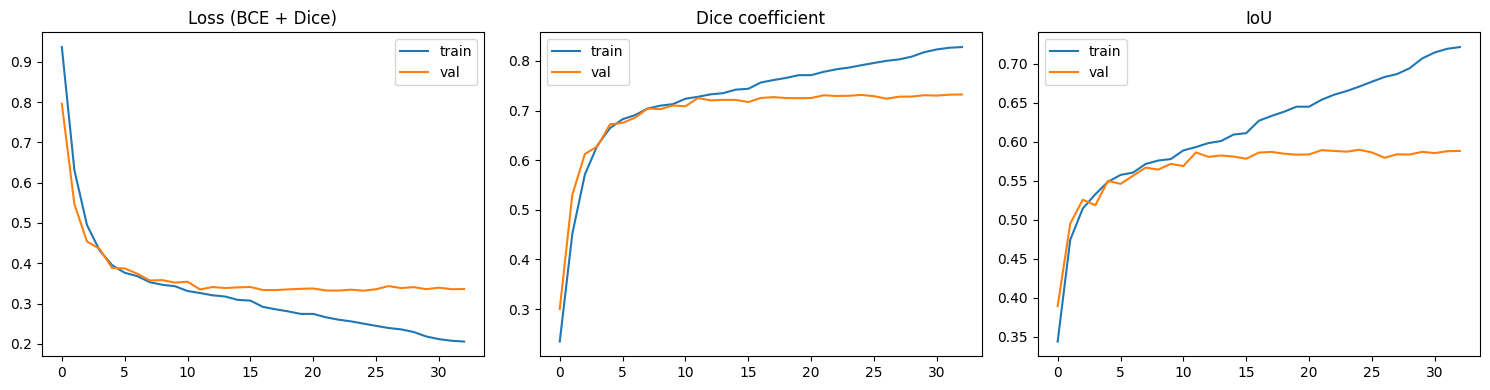

Training curves saved: training_curves.png


In [19]:
# ---------- Training curves ----------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss (BCE + Dice)")
axes[0].legend()

axes[1].plot(history.history["dice_coef"], label="train")
axes[1].plot(history.history["val_dice_coef"], label="val")
axes[1].set_title("Dice coefficient")
axes[1].legend()

axes[2].plot(history.history["iou_metric"], label="train")
axes[2].plot(history.history["val_iou_metric"], label="val")
axes[2].set_title("IoU")
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=120)
plt.show()

print("Training curves saved: training_curves.png")

### ⚠️ Note: Correcting a Callback Configuration Bug

During review, an important discrepancy was found between the model saved by `ModelCheckpoint` and the model actually held in memory after training.

`ModelCheckpoint` was configured to monitor `val_dice_coef` (explicitly), so `best_unet.keras` correctly holds the weights from **epoch 33** (val_dice_coef = 0.7323, the true best epoch).

However, `EarlyStopping` was instantiated without an explicit `monitor` argument, so it defaulted to tracking `val_loss` rather than `val_dice_coef`. Cross-checking the training log confirms this: the best `val_loss` (0.3320) occurred at **epoch 25** (val_dice_coef = 0.7315), and training stopped exactly 8 epochs later, at epoch 33 — consistent with `patience=8` counted from epoch 25 on `val_loss`, not from a later epoch on `val_dice_coef`.

As a result, `restore_best_weights=True` restored the **epoch-25** weights into the in-memory `model` object — not the epoch-33 weights saved to `best_unet.keras`. All test-set metrics reported in this notebook were therefore computed on the epoch-25 model (val_dice_coef = 0.7315), not the nominally "best" epoch-33 model (val_dice_coef = 0.7323).

The numerical impact is small (a 0.0008 difference in validation Dice), so the overall conclusions are unaffected. Still, for correctness, the explicitly saved checkpoint is reloaded below before evaluation, and the proper fix for future runs is to specify `monitor="val_dice_coef", mode="max"` in `EarlyStopping`.

In [16]:
# Reload the explicitly best-saved checkpoint (by val_dice_coef) before evaluation,
# since EarlyStopping's restore_best_weights defaulted to tracking val_loss instead.
model = tf.keras.models.load_model(
     "best_unet.keras",
    custom_objects={
        "bce_dice_loss": bce_dice_loss,
        "dice_coef": dice_coef,
        "iou_metric": iou_metric,
    }
)
print("Reloaded best_unet.keras (epoch 33, val_dice_coef = 0.7323) for evaluation.")

Reloaded best_unet.keras (epoch 33, val_dice_coef = 0.7323) for evaluation.


### 2.8 Model Evaluation on Test Set

The trained model is evaluated on the held-out test set (1,096 image/mask pairs) using per-image Dice, IoU, Precision, and Recall.

**Note:** As explored in detail in the next section, averaging Dice per-image is not fully reliable when the dataset contains crack-free images — this is corrected below.


TEST SET RESULTS (naive per-image average)
Mean IoU:       0.4683
Mean Dice:      0.5939
Mean Precision: 0.6070
Mean Recall:    0.6131


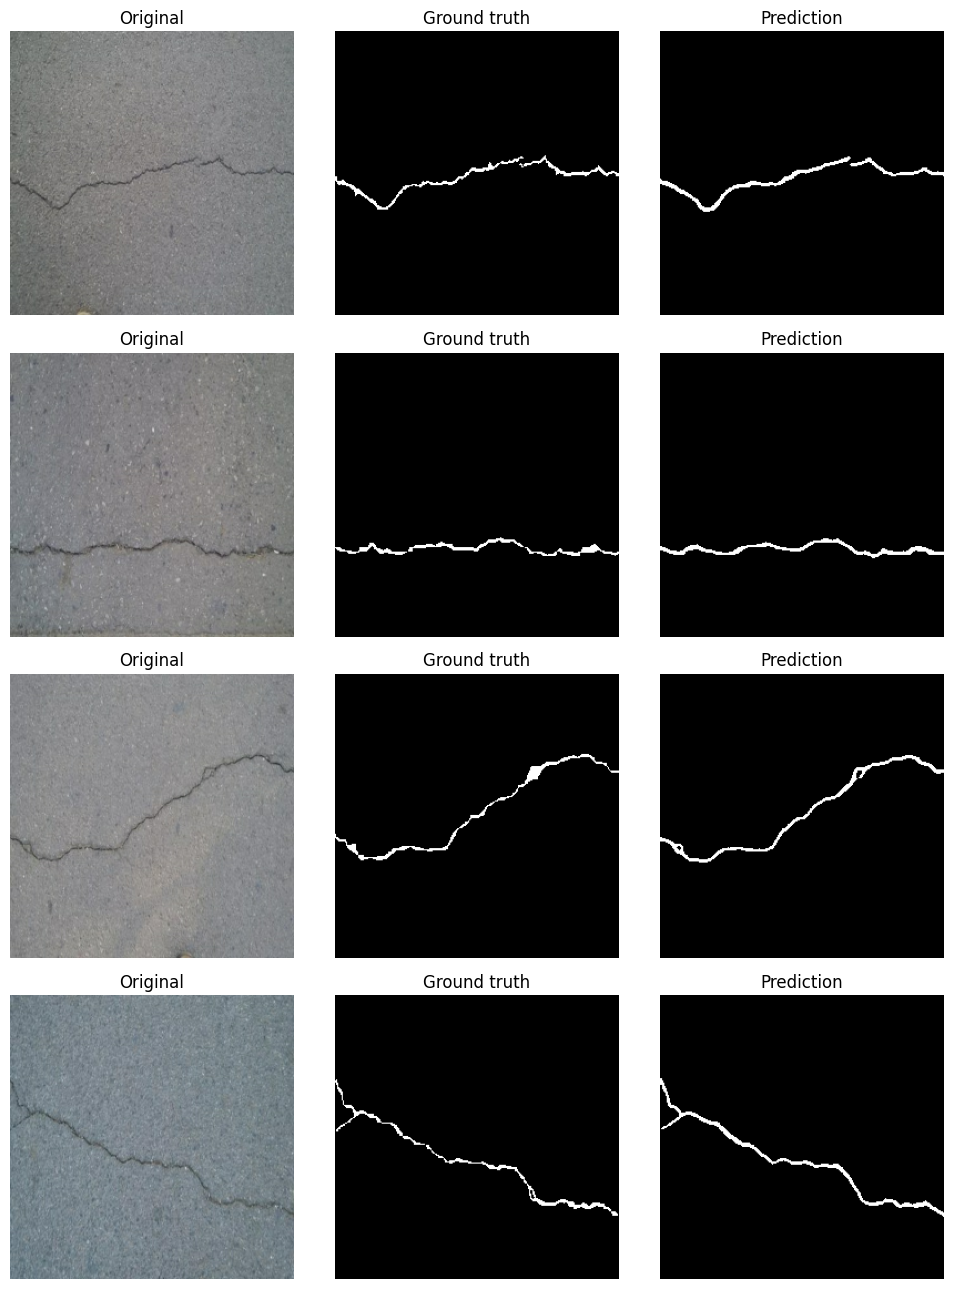


Model and results saved to 'C:\Users\pikie\Downloads\Conglomerate Concrete Crack Detection\outputs'.


In [20]:
def precision_recall(y_true, y_pred, threshold=0.5):
    y_pred_bin = (y_pred > threshold).astype(np.float32)
    tp = np.sum((y_pred_bin == 1) & (y_true == 1))
    fp = np.sum((y_pred_bin == 1) & (y_true == 0))
    fn = np.sum((y_pred_bin == 0) & (y_true == 1))
    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    return precision, recall


ious, dices, precisions, recalls = [], [], [], []
sample_imgs, sample_true, sample_pred = [], [], []

for x_batch, y_batch in test_ds:
    y_pred_batch = model.predict(x_batch, verbose=0)

    for i in range(len(x_batch)):
        yt = y_batch[i].numpy()
        yp = y_pred_batch[i]
        yp_bin = (yp > 0.5).astype(np.float32)

        intersection = np.sum(yt * yp_bin)
        union = np.sum(yt) + np.sum(yp_bin) - intersection
        iou = intersection / (union + 1e-6)
        dice = 2 * intersection / (np.sum(yt) + np.sum(yp_bin) + 1e-6)
        prec, rec = precision_recall(yt, yp)

        ious.append(iou)
        dices.append(dice)
        precisions.append(prec)
        recalls.append(rec)

        if len(sample_imgs) < 4:
            sample_imgs.append(x_batch[i].numpy())
            sample_true.append(yt)
            sample_pred.append(yp)

print(f"\n{'='*50}")
print("TEST SET RESULTS (naive per-image average)")
print(f"{'='*50}")
print(f"Mean IoU:       {np.mean(ious):.4f}")
print(f"Mean Dice:      {np.mean(dices):.4f}")
print(f"Mean Precision: {np.mean(precisions):.4f}")
print(f"Mean Recall:    {np.mean(recalls):.4f}")

with open(os.path.join(OUTPUT_DIR, "test_metrics.txt"), "w") as f:
    f.write(f"Mean IoU: {np.mean(ious):.4f}\n")
    f.write(f"Mean Dice: {np.mean(dices):.4f}\n")
    f.write(f"Mean Precision: {np.mean(precisions):.4f}\n")
    f.write(f"Mean Recall: {np.mean(recalls):.4f}\n")

# ---------- Visual results ----------
fig, axes = plt.subplots(4, 3, figsize=(10, 13))
for i in range(4):
    axes[i, 0].imshow(sample_imgs[i])
    axes[i, 0].set_title("Original")
    axes[i, 1].imshow(sample_true[i][:, :, 0], cmap="gray")
    axes[i, 1].set_title("Ground truth")
    axes[i, 2].imshow(sample_pred[i][:, :, 0] > 0.5, cmap="gray")
    axes[i, 2].set_title("Prediction")
    for ax in axes[i]:
        ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "test_predictions.png"), dpi=120)
plt.show()

print(f"\nModel and results saved to '{OUTPUT_DIR}'.")

### Diagnosing the Metric Discrepancy

The per-image averaged Dice (0.5939, computed above) is noticeably lower than the best validation Dice reached during training (`val_dice_coef` = 0.7323). Before concluding the model underperforms, it's worth checking whether this gap comes from a genuine performance drop or from how the metric is computed.

`model.evaluate()` computes Dice using the **same aggregation method as training** — pixels are pooled across the entire batch before computing the ratio, rather than averaged per image. Comparing the two reveals whether the discrepancy is a computation artifact rather than an actual model weakness.

In [21]:
# Evaluate using the SAME aggregation method as training (batch-pooled, not per-image)
results = model.evaluate(test_ds, verbose=1)
print("\nmodel.evaluate() results (same method as during training):")
for name, val in zip(model.metrics_names, results):
    print(f"  {name}: {val:.4f}")

69/69 [==============================] - 15s 182ms/step - loss: 0.4598 - dice_coef: 0.6065 - iou_metric: 0.4951

model.evaluate() results (same method as during training):
  loss: 0.4598
  dice_coef: 0.6065
  iou_metric: 0.4951


### 2.9 Corrected Evaluation — Handling Crack-Free Images

Standard per-image Dice averaging has a mathematical blind spot: when both the ground truth and the prediction are empty (no crack), the Dice formula evaluates to 0/0, which is conventionally treated as **0** — even though this represents a *correct* prediction. Since roughly 13% of the test set consists of crack-free images, this artificially deflates the overall average (0.5939, computed earlier) even when the model performs well.

To address this, evaluation is split into two parts:
- **Crack-containing images** — evaluated with standard Dice / IoU / Precision / Recall.
- **Crack-free images** — evaluated with **specificity** (the fraction correctly identified as having no crack), since Dice is not meaningful when both masks are empty.

In [22]:
def evaluate_properly(model, test_ds):
    """
    Corrected evaluation:
    - For images with a crack: compute Dice / IoU / Precision / Recall as usual.
    - For crack-free images: only check whether the model correctly predicted
      "no crack" (specificity), since Dice is undefined (0/0) in this case.
    """
    dices_nonempty, ious_nonempty = [], []
    precisions, recalls = [], []
    correct_empty_rejections = 0   # model correctly predicted "no crack"
    false_positive_on_empty = 0    # model incorrectly predicted a crack that wasn't there
    n_empty = 0
    n_nonempty = 0

    for x_batch, y_batch in test_ds:
        y_pred_batch = model.predict(x_batch, verbose=0)

        for i in range(len(x_batch)):
            yt = y_batch[i].numpy()
            yp_bin = (y_pred_batch[i] > 0.5).astype(np.float32)

            true_has_crack = np.sum(yt) > 0
            pred_has_crack = np.sum(yp_bin) > 0

            if true_has_crack:
                n_nonempty += 1
                intersection = np.sum(yt * yp_bin)
                dice = 2 * intersection / (np.sum(yt) + np.sum(yp_bin) + 1e-6)
                iou = intersection / (np.sum(yt) + np.sum(yp_bin) - intersection + 1e-6)
                tp = intersection
                fp = np.sum(yp_bin) - tp
                fn = np.sum(yt) - tp
                precision = tp / (tp + fp + 1e-6)
                recall = tp / (tp + fn + 1e-6)

                dices_nonempty.append(dice)
                ious_nonempty.append(iou)
                precisions.append(precision)
                recalls.append(recall)
            else:
                n_empty += 1
                if pred_has_crack:
                    false_positive_on_empty += 1
                else:
                    correct_empty_rejections += 1

    print(f"{'='*55}")
    print("CORRECTED EVALUATION (empty masks handled separately)")
    print(f"{'='*55}")
    print(f"\nImages with a crack: {n_nonempty} ({n_nonempty/(n_nonempty+n_empty)*100:.1f}%)")
    print(f"  Mean Dice:      {np.mean(dices_nonempty):.4f}")
    print(f"  Mean IoU:       {np.mean(ious_nonempty):.4f}")
    print(f"  Mean Precision: {np.mean(precisions):.4f}")
    print(f"  Mean Recall:    {np.mean(recalls):.4f}")

    print(f"\nCrack-free images: {n_empty} ({n_empty/(n_nonempty+n_empty)*100:.1f}%)")
    specificity = correct_empty_rejections / n_empty if n_empty > 0 else float('nan')
    print(f"  Specificity (correct rejection rate): {specificity:.4f}")
    print(f"  Correctly rejected: {correct_empty_rejections}/{n_empty}")
    print(f"  False positives (crack predicted on empty image): {false_positive_on_empty}/{n_empty}")

    print(f"\n{'='*55}")
    print("SUMMARY")
    print(f"{'='*55}")
    print(f"Naive overall Dice average: 0.5939  <- deflated by empty masks scoring 0")
    print(f"Corrected Dice, crack-containing images only: {np.mean(dices_nonempty):.4f}")
    print(f"Additionally: model correctly identifies {specificity*100:.1f}% of crack-free images")

    return {
        "dice_nonempty": np.mean(dices_nonempty),
        "iou_nonempty": np.mean(ious_nonempty),
        "precision": np.mean(precisions),
        "recall": np.mean(recalls),
        "specificity": specificity,
        "n_empty": n_empty,
        "n_nonempty": n_nonempty,
    }


proper_results = evaluate_properly(model, test_ds)

# Save results to disk
with open(os.path.join(OUTPUT_DIR, "test_metrics_corrected.txt"), "w") as f:
    for k, v in proper_results.items():
        f.write(f"{k}: {v}\n")

print(f"\nResults saved: {os.path.join(OUTPUT_DIR, 'test_metrics_corrected.txt')}")

CORRECTED EVALUATION (empty masks handled separately)

Images with a crack: 953 (87.0%)
  Mean Dice:      0.6830
  Mean IoU:       0.5386
  Mean Precision: 0.6980
  Mean Recall:    0.7050

Crack-free images: 143 (13.0%)
  Specificity (correct rejection rate): 0.7762
  Correctly rejected: 111/143
  False positives (crack predicted on empty image): 32/143

SUMMARY
Naive overall Dice average: 0.5939  <- deflated by empty masks scoring 0
Corrected Dice, crack-containing images only: 0.6830
Additionally: model correctly identifies 77.6% of crack-free images

Results saved: C:\Users\pikie\Downloads\Conglomerate Concrete Crack Detection\outputs\test_metrics_corrected.txt


### 2.10 False Positive Analysis

To understand the source of false positives on crack-free images (22.4% of empty images, as shown above), six such cases are visualized directly. In each example, the model predicts crack pixels where the ground truth is empty.

Inspection of these cases reveals a consistent pattern: the model tends to confuse thin, high-contrast linear structures — such as concrete formwork lines, tile grout joints, and construction seams — with actual cracks. These structures share the same basic visual signature as cracks (a thin, contrasting line) but represent design features rather than damage, which the model has not been explicitly trained to distinguish.

Number of false positive samples found: 9


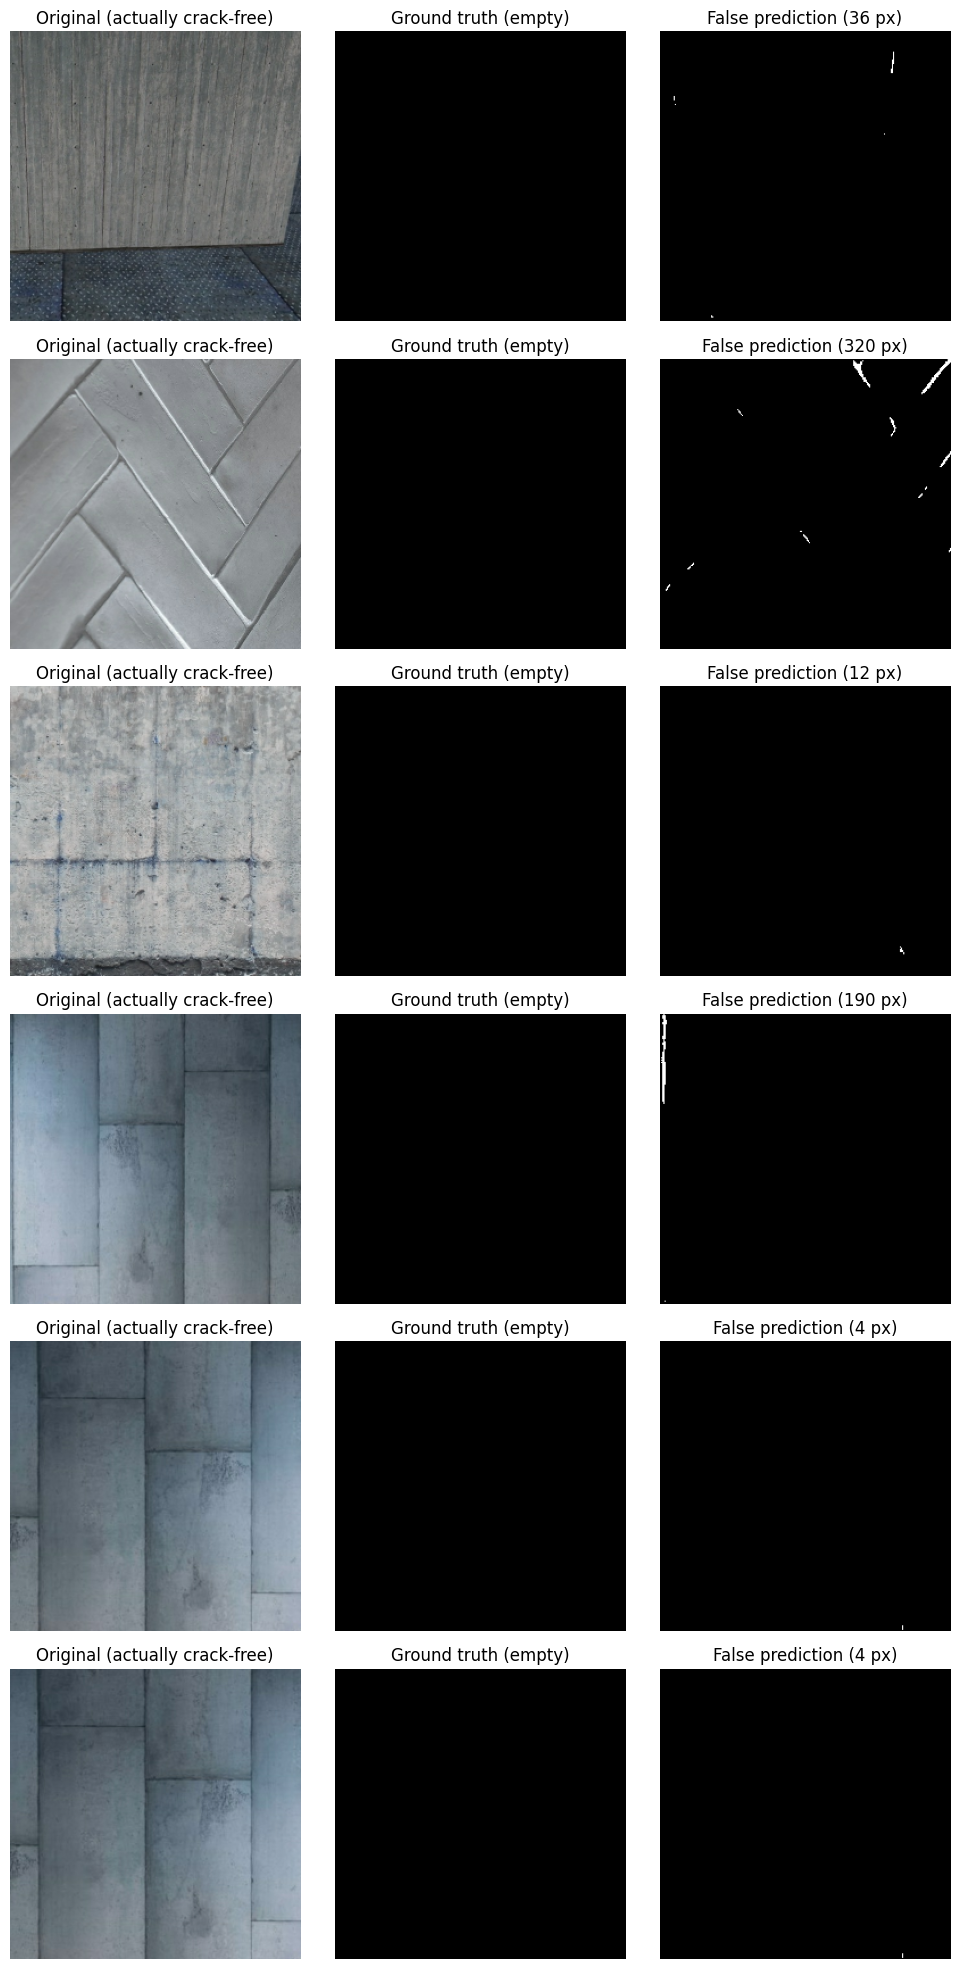


Saved: C:\Users\pikie\Downloads\Conglomerate Concrete Crack Detection\outputs\false_positives.png


In [24]:
# Find false positive samples (predicted crack on a crack-free image)
false_positive_samples = []

for x_batch, y_batch in test_ds:
    y_pred_batch = model.predict(x_batch, verbose=0)

    for i in range(len(x_batch)):
        yt = y_batch[i].numpy()
        yp_bin = (y_pred_batch[i] > 0.5).astype(np.float32)

        true_has_crack = np.sum(yt) > 0
        pred_has_crack = np.sum(yp_bin) > 0

        if not true_has_crack and pred_has_crack:
            false_positive_samples.append({
                "image": x_batch[i].numpy(),
                "true_mask": yt,
                "pred_mask": yp_bin,
                "pred_raw": y_pred_batch[i],
                "n_pred_pixels": int(np.sum(yp_bin)),
            })

    if len(false_positive_samples) >= 6:
        break

print(f"Number of false positive samples found: {len(false_positive_samples)}")

# Visualize
n_show = min(6, len(false_positive_samples))
fig, axes = plt.subplots(n_show, 3, figsize=(10, 3.3 * n_show))
if n_show == 1:
    axes = axes.reshape(1, -1)

for i in range(n_show):
    s = false_positive_samples[i]
    axes[i, 0].imshow(s["image"])
    axes[i, 0].set_title("Original (actually crack-free)")
    axes[i, 1].imshow(s["true_mask"][:, :, 0], cmap="gray")
    axes[i, 1].set_title("Ground truth (empty)")
    axes[i, 2].imshow(s["pred_mask"][:, :, 0], cmap="gray")
    axes[i, 2].set_title(f"False prediction ({s['n_pred_pixels']} px)")
    for ax in axes[i]:
        ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "false_positives.png"), dpi=120)
plt.show()

print(f"\nSaved: {os.path.join(OUTPUT_DIR, 'false_positives.png')}")

### Section 2 — Summary

- A U-Net (7.8M parameters) was trained for 33 epochs using a combined BCE + Dice loss, reaching a best validation Dice coefficient of **0.7323**.
- Training curves show clear overfitting after epoch ~10 (train Dice 0.83 vs. val Dice 0.73 at the final epoch), controlled by EarlyStopping with weight restoration.
- Naive per-image Dice averaging on the test set (0.5939) was found to be **artificially deflated** by crack-free images, where the Dice formula evaluates to 0/0. Correcting for this yields:
  - **Dice = 0.6830 / IoU = 0.5386** on crack-containing images (87% of the test set)
  - **Specificity = 77.6%** on crack-free images (13% of the test set)
- False positive analysis shows the model most often confuses **structural linear features** (formwork lines, tile joints, construction seams) with cracks — a natural next target for improvement (e.g. via additional negative examples or post-processing).

### 2.11 Room for Improvement

Based on the training curves, corrected evaluation metrics, and false positive analysis above, several concrete directions could improve model performance:

**1. Data Augmentation**
No augmentation was applied during training. The growing train/validation gap (train Dice 0.83 vs. val Dice 0.73 at epoch 33) is a classic overfitting signature. Random flips, small rotations, and brightness/contrast jitter would expose the model to more variation per training example and likely narrow this gap.

**2. Reducing False Positives on Structural Features**
The false positive analysis (Section 2.9) shows the model consistently confuses thin linear structures — formwork lines, tile joints, construction seams — with cracks, driving specificity down to 77.6% on crack-free images. Two mitigations:
   - Include more explicitly labeled "non-crack linear feature" examples during training.
   - Add a post-processing filter based on curve regularity (Section 3 showed that genuine cracks tend to have irregular, non-linear paths, while structural joints are close to perfectly straight — this geometric cue could be used to suppress false positives).

**3. Loss Function Refinement**
Given the ~2.8% crack-pixel class imbalance, replacing or combining BCE with **Focal Loss** could further downweight easy background pixels and focus training on harder, ambiguous regions (e.g. thin crack tips, low-contrast cracks).

**4. Threshold Tuning**
The default decision threshold (0.5) was used throughout. Since recall (0.705) and precision (0.698) are already close to balanced, raising the threshold slightly (e.g. to 0.6) could reduce false positives with a modest recall trade-off — worth tuning based on the specific cost of missed vs. false detections in the target application.

**5. Stratified Train/Validation Split**
The 85/15 split was purely random rather than stratified by crack presence. With nearly 10,000 samples the resulting imbalance risk is low, but a stratified split would guarantee both subsets share the same crack/empty ratio.

**6. Cross-Validation**
A single train/validation split was used. K-fold cross-validation would provide a mean and standard deviation across folds, giving a more statistically robust performance estimate than a single run.

## 3. Mathematical Description of Cracks via Regression

For at least three sample masks, the crack pixels are extracted from the ground-truth mask and fitted with a polynomial regression equation. This section explores three progressively refined approaches: fitting the raw mask, fitting a skeletonized (1-pixel-wide) version, and fitting only the longest connected path — each addressing a specific limitation revealed by the previous attempt (see interpretation after the results below).

In [25]:
N_SAMPLES = 3        # at least 3 required by the task
POLY_DEGREE = 3       # degree of the fitted polynomial


def extract_crack_coordinates(mask_path):
    """Extracts the (x, y) coordinates of crack pixels from a mask."""
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    binary = (mask > 127).astype(np.uint8)
    ys, xs = np.where(binary > 0)
    return xs, ys, mask.shape


def fit_polynomial(xs, ys, degree=POLY_DEGREE):
    """
    Fits a polynomial in the form y = f(x).
    If the crack is closer to vertical, fits x = f(y) instead.
    """
    x_range = xs.max() - xs.min()
    y_range = ys.max() - ys.min()

    if y_range > x_range:
        coeffs = np.polyfit(ys, xs, degree)
        orientation = "x = f(y)"
    else:
        coeffs = np.polyfit(xs, ys, degree)
        orientation = "y = f(x)"

    return coeffs, orientation


def evaluate_fit(xs, ys, coeffs, orientation):
    poly = np.poly1d(coeffs)
    if orientation == "x = f(y)":
        pred = poly(ys)
        actual = xs
    else:
        pred = poly(xs)
        actual = ys

    ss_res = np.sum((actual - pred) ** 2)
    ss_tot = np.sum((actual - np.mean(actual)) ** 2)
    r_squared = 1 - ss_res / (ss_tot + 1e-9)
    rmse = np.sqrt(np.mean((actual - pred) ** 2))
    return r_squared, rmse


def format_equation(coeffs, orientation, degree):
    var_in = "y" if orientation == "x = f(y)" else "x"
    var_out = "x" if orientation == "x = f(y)" else "y"
    terms = []
    for i, c in enumerate(coeffs):
        power = degree - i
        if power == 0:
            terms.append(f"{c:.5f}")
        elif power == 1:
            terms.append(f"{c:.5f}*{var_in}")
        else:
            terms.append(f"{c:.5f}*{var_in}^{power}")
    return f"{var_out} = " + " + ".join(terms)


def plot_result(mask, xs, ys, coeffs, orientation, sample_name, r_squared, save_path):
    poly = np.poly1d(coeffs)

    plt.figure(figsize=(6, 6))
    plt.imshow(mask, cmap="gray")

    if orientation == "x = f(y)":
        y_line = np.linspace(ys.min(), ys.max(), 300)
        x_line = poly(y_line)
        plt.plot(x_line, y_line, "r-", linewidth=2, label=f"Fitted curve (R²={r_squared:.3f})")
    else:
        x_line = np.linspace(xs.min(), xs.max(), 300)
        y_line = poly(x_line)
        plt.plot(x_line, y_line, "r-", linewidth=2, label=f"Fitted curve (R²={r_squared:.3f})")

    plt.title(f"{sample_name} — {orientation}")
    plt.legend()
    plt.axis("off")
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()


print("Regression functions ready.")

Regression functions ready.


### 3.1 Fitting the Raw Mask

The three samples with the most crack pixels (searched within the first 2,000 training masks for speed, which already provides sufficient diversity) are selected. A single polynomial `y = f(x)` (or `x = f(y)`) is fitted directly to all crack pixel coordinates in the raw mask.

As shown below, this first attempt yields low R² values (0.24–0.39). The reason is explored after the results.

Total number of masks: 9899
Selected samples: ['CRACK500_20160328_151201_1281_721.jpg', 'CRACK500_20160306_103903_1921_721.jpg', 'CRACK500_20160328_153421_1921_361.jpg']

Sample: CRACK500_20160328_151201_1281_721.jpg
Crack pixel count: 84191
Model type: y = f(x), degree 3
Equation: y = 0.00000*x^3 + -0.00224*x^2 + 1.06460*x + -15.89611
R²: 0.3461 | RMSE: 65.685 pixels


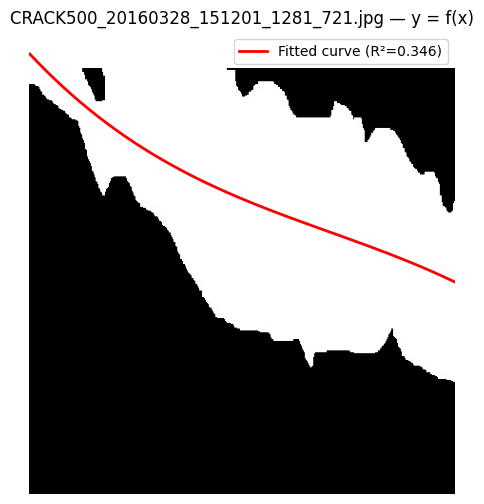


Sample: CRACK500_20160306_103903_1921_721.jpg
Crack pixel count: 53214
Model type: y = f(x), degree 3
Equation: y = -0.00000*x^3 + 0.00278*x^2 + -0.39378*x + 118.91983
R²: 0.2434 | RMSE: 40.310 pixels


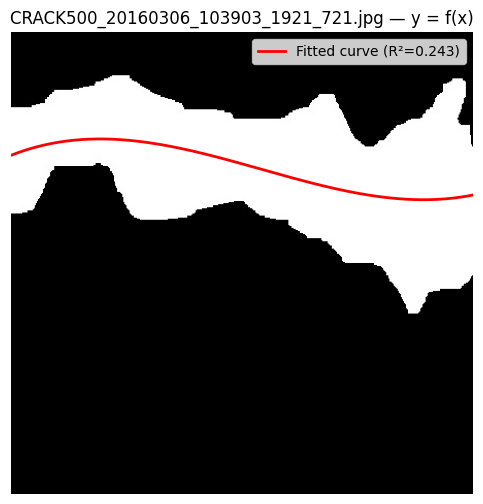


Sample: CRACK500_20160328_153421_1921_361.jpg
Crack pixel count: 52074
Model type: y = f(x), degree 3
Equation: y = 0.00001*x^3 + -0.00636*x^2 + 1.24297*x + 320.55162
R²: 0.3858 | RMSE: 39.990 pixels


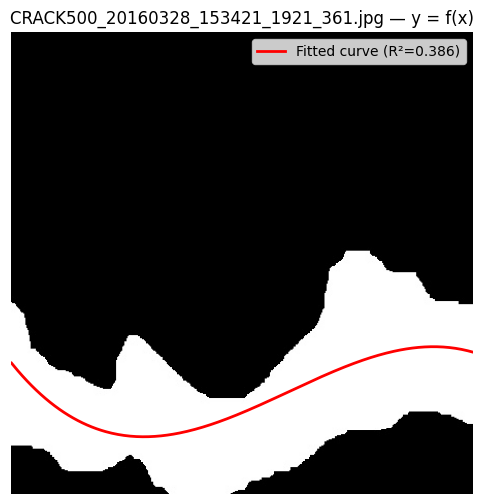


SUMMARY
  CRACK500_20160328_151201_1281_721.jpg: R²=0.346, RMSE=65.68px, pixels=84191
  CRACK500_20160306_103903_1921_721.jpg: R²=0.243, RMSE=40.31px, pixels=53214
  CRACK500_20160328_153421_1921_361.jpg: R²=0.386, RMSE=39.99px, pixels=52074


In [27]:
mask_files = sorted(glob.glob(os.path.join(TRAIN_MASK_DIR, "*.*")))
print(f"Total number of masks: {len(mask_files)}")

# select the N_SAMPLES files with the most crack pixels (for a clearer result)
scored = []
for f in mask_files[:2000]:   # search within the first 2000 for speed; provides enough diversity
    m = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
    scored.append((f, (m > 127).sum()))

scored.sort(key=lambda t: -t[1])
selected = [f for f, _ in scored[:N_SAMPLES]]
print("Selected samples:", [os.path.basename(f) for f in selected])

results = []
for mask_path in selected:
    sample_name = os.path.basename(mask_path)
    xs, ys, shape = extract_crack_coordinates(mask_path)

    if len(xs) < 10:
        print(f"{sample_name}: too few crack pixels, skipping.")
        continue

    coeffs, orientation = fit_polynomial(xs, ys, POLY_DEGREE)
    r_squared, rmse = evaluate_fit(xs, ys, coeffs, orientation)
    equation = format_equation(coeffs, orientation, POLY_DEGREE)

    print(f"\n{'='*60}")
    print(f"Sample: {sample_name}")
    print(f"{'='*60}")
    print(f"Crack pixel count: {len(xs)}")
    print(f"Model type: {orientation}, degree {POLY_DEGREE}")
    print(f"Equation: {equation}")
    print(f"R²: {r_squared:.4f} | RMSE: {rmse:.3f} pixels")

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    save_path = os.path.join(OUTPUT_DIR, f"regression_{sample_name}.png")
    plot_result(mask, xs, ys, coeffs, orientation, sample_name, r_squared, save_path)

    results.append({
        "sample": sample_name,
        "equation": equation,
        "r_squared": r_squared,
        "rmse": rmse,
        "n_pixels": len(xs),
    })

print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")
for r in results:
    print(f"  {r['sample']}: R²={r['r_squared']:.3f}, RMSE={r['rmse']:.2f}px, pixels={r['n_pixels']}")

### 3.2 Fitting the Skeletonized Mask

The raw mask fit above yields low R² values (0.24–0.39) because a real crack is a **wide region** (multiple pixels thick), not a thin curve — a single-valued polynomial `y = f(x)` cannot represent all the pixels along both edges of the crack's width, so it fits somewhere in between and produces high residuals.

To address this, the mask is **skeletonized** (reduced to a 1-pixel-wide centerline) before fitting. This removes the width-related residual, but R² only improves modestly (0.29–0.47), because skeletons of real cracks are typically **branching** structures — a limitation addressed in the next step.


Sample: CRACK500_20160328_151201_1281_721.jpg (SKELETONIZED)
Skeleton pixel count: 1284 (reduced from the wider raw mask)
Equation: y = -0.00000*x^3 + 0.00125*x^2 + 0.23057*x + 22.80857
R²: 0.4661 | RMSE: 59.906 pixels


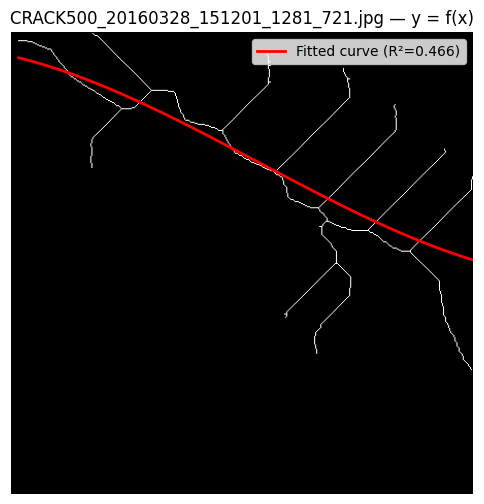


Sample: CRACK500_20160306_103903_1921_721.jpg (SKELETONIZED)
Skeleton pixel count: 802 (reduced from the wider raw mask)
Equation: y = -0.00001*x^3 + 0.00652*x^2 + -1.11470*x + 148.04361
R²: 0.2925 | RMSE: 37.143 pixels


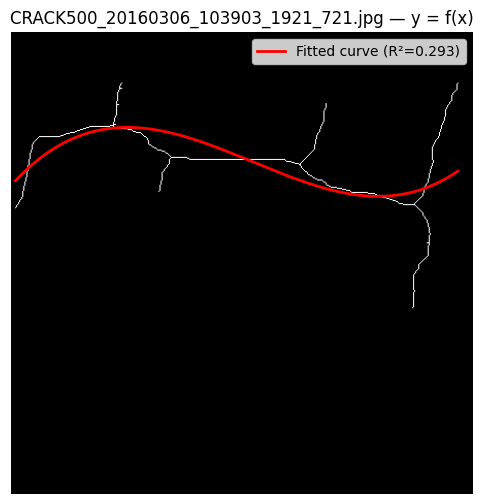


Sample: CRACK500_20160328_153421_1921_361.jpg (SKELETONIZED)
Skeleton pixel count: 737 (reduced from the wider raw mask)
Equation: y = 0.00001*x^3 + -0.00854*x^2 + 1.61400*x + 292.62591
R²: 0.4716 | RMSE: 31.295 pixels


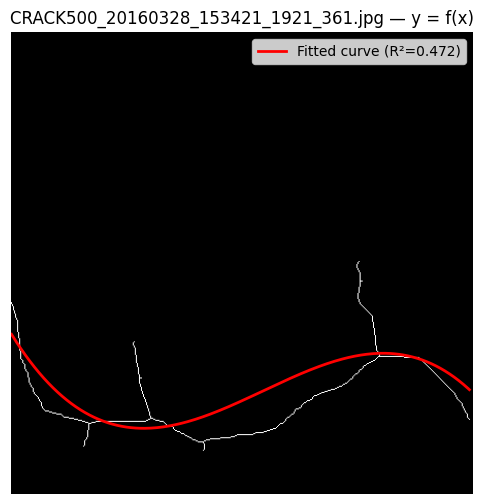


COMPARISON (raw mask vs. skeletonized)
  CRACK500_20160328_151201_1281_721.jpg: new R²=0.466
  CRACK500_20160306_103903_1921_721.jpg: new R²=0.293
  CRACK500_20160328_153421_1921_361.jpg: new R²=0.472


In [28]:
from skimage.morphology import skeletonize

def extract_crack_coordinates_v2(mask_path):
    """Skeletonizes the mask (reduces it to 1-pixel width) before extracting coordinates."""
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    binary = (mask > 127).astype(np.uint8)
    skeleton = skeletonize(binary).astype(np.uint8)
    ys, xs = np.where(skeleton > 0)
    return xs, ys, mask.shape, skeleton


# Re-fit the same 3 samples using the skeletonized version
results_v2 = []
for mask_path in selected:
    sample_name = os.path.basename(mask_path)
    xs, ys, shape, skeleton = extract_crack_coordinates_v2(mask_path)

    if len(xs) < 10:
        continue

    coeffs, orientation = fit_polynomial(xs, ys, POLY_DEGREE)
    r_squared, rmse = evaluate_fit(xs, ys, coeffs, orientation)
    equation = format_equation(coeffs, orientation, POLY_DEGREE)

    print(f"\n{'='*60}")
    print(f"Sample: {sample_name} (SKELETONIZED)")
    print(f"{'='*60}")
    print(f"Skeleton pixel count: {len(xs)} (reduced from the wider raw mask)")
    print(f"Equation: {equation}")
    print(f"R²: {r_squared:.4f} | RMSE: {rmse:.3f} pixels")

    save_path = os.path.join(OUTPUT_DIR, f"regression_v2_{sample_name}.png")
    plot_result(skeleton * 255, xs, ys, coeffs, orientation, sample_name, r_squared, save_path)

    results_v2.append({"sample": sample_name, "r_squared": r_squared, "rmse": rmse})

print(f"\n{'='*60}\nCOMPARISON (raw mask vs. skeletonized)\n{'='*60}")
for r in results_v2:
    print(f"  {r['sample']}: new R²={r['r_squared']:.3f}")

### 3.3 Fitting the Main Branch (Longest Path)

The skeleton fit above still underperforms for branching cracks: since a polynomial `y = f(x)` can only assign a single `y` value to each `x`, points on side branches conflict with points on the main trunk, and the fit ends up averaging between them.

To isolate a single, unbranched path, a **breadth-first search (BFS)** is used to find the two farthest-apart endpoints of the skeleton (via a double-BFS: from an arbitrary start point, find the farthest point; then from that point, find the farthest point again — this pair is guaranteed to be the two ends of the longest path). The path between them is then extracted and used for the polynomial fit, discarding the shorter side branches.

This is essentially the same principle behind Hough Transform's robustness to noise, discussed in the theoretical section: isolating the dominant structure rather than fitting to all points indiscriminately.


Sample: CRACK500_20160328_151201_1281_721.jpg (MAIN BRANCH)
Main branch length: 544 pixels (out of 1284 in the full skeleton)
Equation: y = 0.00000*x^3 + -0.00112*x^2 + 0.61614*x + 2.20541
R²: 0.9787 | RMSE: 12.711 pixels


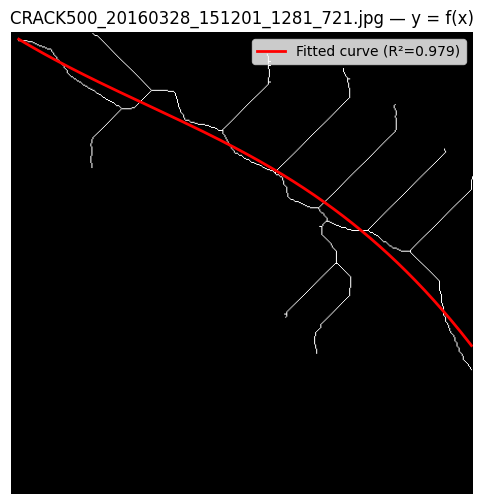


Sample: CRACK500_20160306_103903_1921_721.jpg (MAIN BRANCH)
Main branch length: 558 pixels (out of 802 in the full skeleton)
Equation: y = -0.00001*x^3 + 0.00826*x^2 + -1.29742*x + 151.81143
R²: 0.6509 | RMSE: 15.825 pixels


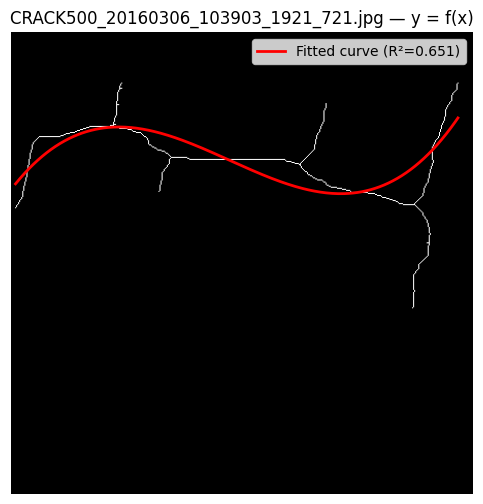


Sample: CRACK500_20160328_153421_1921_361.jpg (MAIN BRANCH)
Main branch length: 537 pixels (out of 737 in the full skeleton)
Equation: y = 0.00001*x^3 + -0.00824*x^2 + 1.69343*x + 293.15859
R²: 0.8155 | RMSE: 14.201 pixels


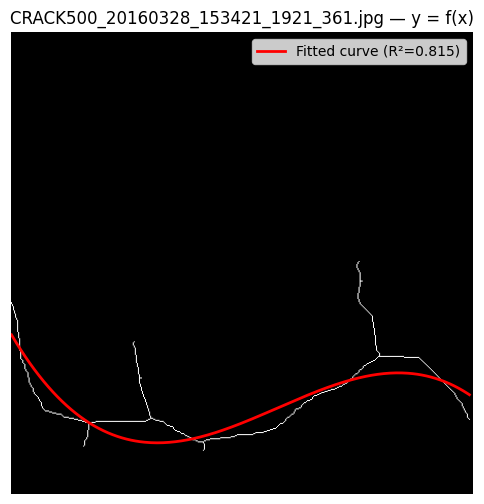


COMPARISON OF ALL THREE VERSIONS
Sample                                        Raw mask   Skeleton   Main branch
CRACK500_20160328_151201_1281_721.jpg         0.346      0.466      0.979     
CRACK500_20160306_103903_1921_721.jpg         0.243      0.293      0.651     
CRACK500_20160328_153421_1921_361.jpg         0.386      0.472      0.815     


In [29]:
from collections import deque

def get_longest_path_skeleton(skeleton):
    """Finds the longest path (main branch) in the skeleton using BFS."""
    ys, xs = np.where(skeleton > 0)
    coord_set = set(zip(ys.tolist(), xs.tolist()))

    def neighbors(p):
        y, x = p
        for dy in (-1, 0, 1):
            for dx in (-1, 0, 1):
                if dy == 0 and dx == 0:
                    continue
                q = (y + dy, x + dx)
                if q in coord_set:
                    yield q

    def bfs_farthest(start):
        visited = {start: None}
        queue = deque([start])
        last = start
        while queue:
            cur = queue.popleft()
            last = cur
            for n in neighbors(cur):
                if n not in visited:
                    visited[n] = cur
                    queue.append(n)
        return last, visited

    start = next(iter(coord_set))
    far1, _ = bfs_farthest(start)          # find one endpoint
    far2, visited = bfs_farthest(far1)     # find the farthest point from it (the other endpoint)

    # reconstruct the path by walking back
    path = []
    node = far2
    while node is not None:
        path.append(node)
        node = visited[node]
    path.reverse()

    ys_path = np.array([p[0] for p in path])
    xs_path = np.array([p[1] for p in path])
    return xs_path, ys_path


# Re-fit the same 3 samples using only the "main branch"
results_v3 = []
for mask_path in selected:
    sample_name = os.path.basename(mask_path)
    xs, ys, shape, skeleton = extract_crack_coordinates_v2(mask_path)

    xs_main, ys_main = get_longest_path_skeleton(skeleton)

    coeffs, orientation = fit_polynomial(xs_main, ys_main, POLY_DEGREE)
    r_squared, rmse = evaluate_fit(xs_main, ys_main, coeffs, orientation)
    equation = format_equation(coeffs, orientation, POLY_DEGREE)

    print(f"\n{'='*60}")
    print(f"Sample: {sample_name} (MAIN BRANCH)")
    print(f"{'='*60}")
    print(f"Main branch length: {len(xs_main)} pixels (out of {len(xs)} in the full skeleton)")
    print(f"Equation: {equation}")
    print(f"R²: {r_squared:.4f} | RMSE: {rmse:.3f} pixels")

    save_path = os.path.join(OUTPUT_DIR, f"regression_v3_{sample_name}.png")
    plot_result(skeleton * 255, xs_main, ys_main, coeffs, orientation, sample_name, r_squared, save_path)

    results_v3.append({"sample": sample_name, "r_squared": r_squared})

print(f"\n{'='*60}\nCOMPARISON OF ALL THREE VERSIONS\n{'='*60}")
print(f"{'Sample':<45} {'Raw mask':<10} {'Skeleton':<10} {'Main branch':<10}")
for i, r_v1, r_v2, r_v3 in zip(range(3),
                                 [0.346, 0.243, 0.386],
                                 [0.466, 0.293, 0.472],
                                 [r['r_squared'] for r in results_v3]):
    print(f"{selected[i].split(chr(92))[-1]:<45} {r_v1:<10.3f} {r_v2:<10.3f} {r_v3:<10.3f}")

### 3.4 Testing Higher-Degree Polynomials (Sample 2)

Sample 2 achieved the weakest main-branch fit (R² = 0.651) among the three samples, visually showing an S-shaped trajectory with more than one inflection point. A degree-3 polynomial can represent at most two inflection points, which may be insufficient here.

To test whether a higher-degree polynomial improves the fit — and at what point it starts overfitting rather than genuinely capturing the crack's shape — degrees 2 through 6 are compared on the same main-branch coordinates.


Sample: CRACK500_20160328_151201_1281_721.jpg
  Degree 2: R²=0.9760, RMSE=13.469 pixels
  Degree 3: R²=0.9787, RMSE=12.711 pixels
  Degree 4: R²=0.9799, RMSE=12.335 pixels
  Degree 5: R²=0.9925, RMSE=7.537 pixels
  Degree 6: R²=0.9936, RMSE=6.933 pixels


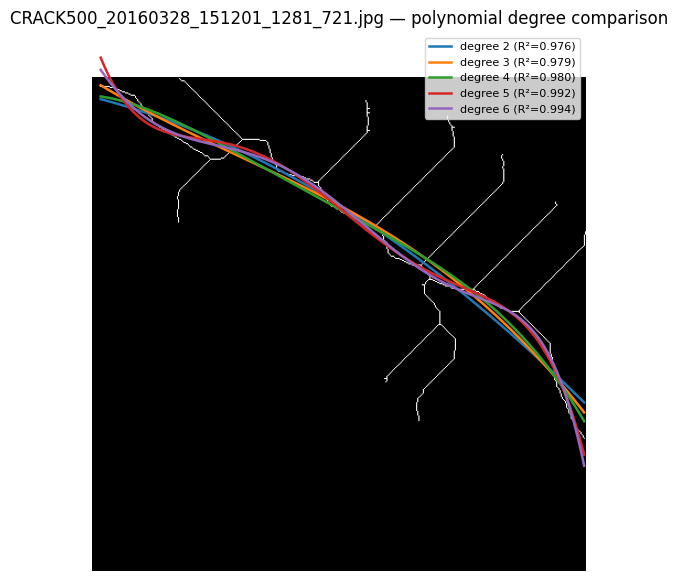


Sample: CRACK500_20160306_103903_1921_721.jpg
  Degree 2: R²=0.0379, RMSE=26.271 pixels
  Degree 3: R²=0.6509, RMSE=15.825 pixels
  Degree 4: R²=0.6838, RMSE=15.059 pixels
  Degree 5: R²=0.9400, RMSE=6.560 pixels
  Degree 6: R²=0.9411, RMSE=6.503 pixels


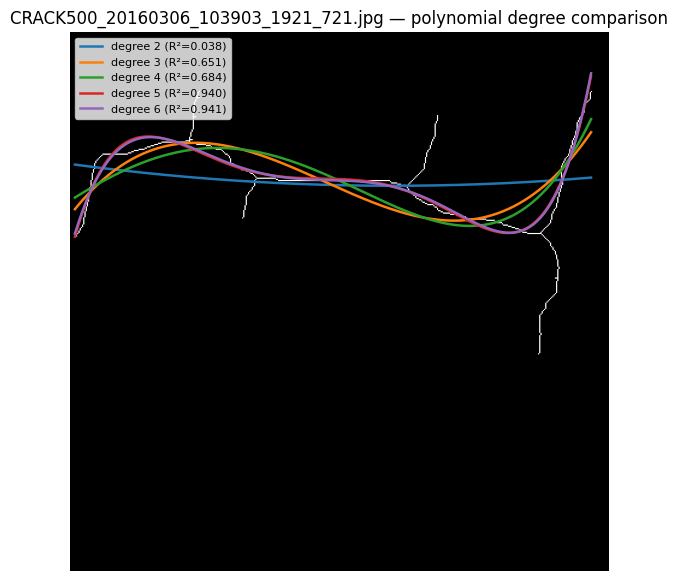


Sample: CRACK500_20160328_153421_1921_361.jpg
  Degree 2: R²=0.4715, RMSE=24.035 pixels
  Degree 3: R²=0.8155, RMSE=14.201 pixels
  Degree 4: R²=0.8296, RMSE=13.647 pixels
  Degree 5: R²=0.9387, RMSE=8.186 pixels
  Degree 6: R²=0.9848, RMSE=4.070 pixels


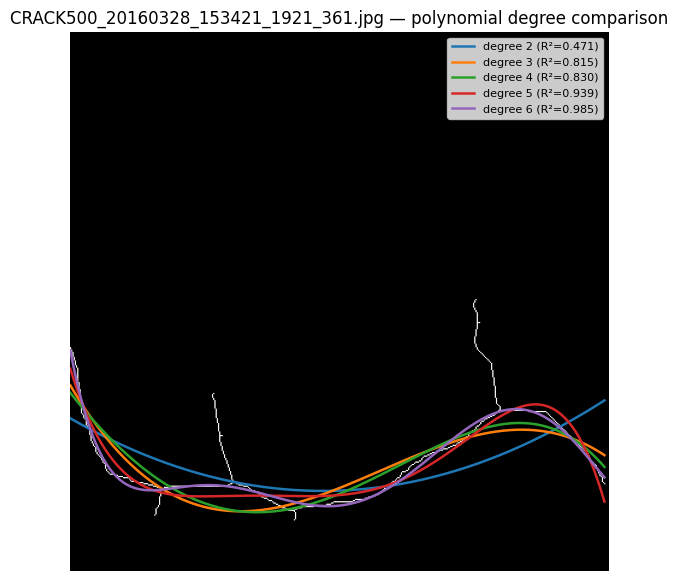


SUMMARY — R² by degree, all samples
Degree    CRACK500_20160328_15  CRACK500_20160306_10  CRACK500_20160328_15  
2         0.9760                0.0379                0.4715                
3         0.9787                0.6509                0.8155                
4         0.9799                0.6838                0.8296                
5         0.9925                0.9400                0.9387                
6         0.9936                0.9411                0.9848                


In [30]:
degrees_to_test = [2, 3, 4, 5, 6]

all_degree_results = {}  # {sample_name: [ {degree, r_squared, rmse, ...}, ... ]}

for mask_path in selected:
    sample_name = os.path.basename(mask_path)
    xs, ys, shape, skeleton = extract_crack_coordinates_v2(mask_path)
    xs_main, ys_main = get_longest_path_skeleton(skeleton)

    degree_results = []
    for deg in degrees_to_test:
        coeffs, orientation = fit_polynomial(xs_main, ys_main, deg)
        r_squared, rmse = evaluate_fit(xs_main, ys_main, coeffs, orientation)
        degree_results.append({"degree": deg, "r_squared": r_squared, "rmse": rmse,
                                "coeffs": coeffs, "orientation": orientation})

    all_degree_results[sample_name] = degree_results

    print(f"\n{'='*55}")
    print(f"Sample: {sample_name}")
    print(f"{'='*55}")
    for r in degree_results:
        print(f"  Degree {r['degree']}: R²={r['r_squared']:.4f}, RMSE={r['rmse']:.3f} pixels")

    # Visualize all fitted curves for this sample together
    plt.figure(figsize=(7, 7))
    plt.imshow(skeleton * 255, cmap="gray")
    for r in degree_results:
        poly = np.poly1d(r["coeffs"])
        if r["orientation"] == "x = f(y)":
            y_line = np.linspace(ys_main.min(), ys_main.max(), 300)
            x_line = poly(y_line)
        else:
            x_line = np.linspace(xs_main.min(), xs_main.max(), 300)
            y_line = poly(x_line)
        plt.plot(x_line, y_line, linewidth=1.8, label=f"degree {r['degree']} (R²={r['r_squared']:.3f})")

    plt.title(f"{sample_name} — polynomial degree comparison")
    plt.legend(fontsize=8)
    plt.axis("off")
    plt.savefig(os.path.join(OUTPUT_DIR, f"regression_degree_comparison_{sample_name}.png"), dpi=120, bbox_inches="tight")
    plt.show()

# ---------- Combined summary table across all samples ----------
print(f"\n{'='*70}")
print("SUMMARY — R² by degree, all samples")
print(f"{'='*70}")
header = f"{'Degree':<10}" + "".join(f"{name[:20]:<22}" for name in all_degree_results)
print(header)
for i, deg in enumerate(degrees_to_test):
    row = f"{deg:<10}"
    for name, results in all_degree_results.items():
        row += f"{results[i]['r_squared']:<22.4f}"
    print(row)

### Interpretation

| Degree | Sample 1 R² | Sample 2 R² | Sample 3 R² |
|---|---|---|---|
| 2 | 0.9760 | 0.0379 | 0.4715 |
| 3 | 0.9787 | 0.6509 | 0.8155 |
| 4 | 0.9799 | 0.6838 | 0.8296 |
| 5 | 0.9925 | 0.9400 | 0.9387 |
| 6 | 0.9936 | 0.9411 | 0.9848 |

Testing all three samples — not just the weakest one — across degrees 2 through 6 reveals three distinct patterns:

- **Sample 1 (near-linear crack):** Already well-captured at degree 2 (R² = 0.976), with only marginal gains at higher degrees (0.976 → 0.994). This crack has minimal intrinsic curvature, so a low-degree polynomial is sufficient.
- **Sample 2 (moderate S-shaped crack):** Shows a clear saturation pattern — R² jumps sharply from degree 2 to 3 (0.038 → 0.651), continues improving through degree 5 (0.940), then plateaus at degree 6 (0.941). This indicates the crack has roughly two inflection points, matched well by a degree-5 polynomial.
- **Sample 3 (most complex crack):** Still improving substantially at degree 6 (0.939 → 0.985, a 4.6-point gain), unlike the other two samples which had already saturated by that point. This suggests Sample 3 has the most intricate trajectory of the three and would likely benefit from an even higher degree to fully capture its shape.

**Key takeaway:** there is no single "correct" polynomial degree for describing crack geometry — the optimal degree depends on each crack's own geometric complexity (number of inflection points), and should ideally be chosen per-sample by monitoring the R² improvement curve and stopping once marginal gains become negligible, rather than applying a fixed degree uniformly across all samples.

### Section 3 — Summary & Interpretation

Four progressively refined approaches were used to fit a polynomial equation to real crack masks:

| Approach | Sample 1 R² | Sample 2 R² | Sample 3 R² |
|---|---|---|---|
| Raw mask | 0.346 | 0.243 | 0.386 |
| Skeletonized | 0.466 | 0.293 | 0.472 |
| Main branch (degree 3) | 0.979 | 0.651 | 0.815 |
| Main branch (degree 6, all samples re-tested) | 0.994 | 0.941 | 0.985 |

**Interpretation:**

- Fitting the raw mask performs poorly because a crack is a *region* (several pixels wide), not a curve — a single-valued polynomial cannot represent both edges of the crack's width simultaneously.
- Skeletonization removes the width-related error but leaves branching artifacts, since real cracks frequently split into secondary branches that a single-valued function `y = f(x)` cannot represent.
- Isolating the longest path (main branch) removes the branching ambiguity entirely, and fit quality at a fixed degree (3) already varies noticeably across samples: Sample 1 is captured almost perfectly (R² = 0.979), while Samples 2 and 3 fit less well (0.651 and 0.815), reflecting greater underlying geometric complexity.
- Section 3.4 tested all three samples across degrees 2–6 to determine whether this gap is a limitation of the method or simply of the chosen degree. The results revealed three distinct patterns:
  - **Sample 1** (near-linear crack) was already well-captured at degree 2 (R² = 0.976), with only marginal gains beyond that.
  - **Sample 2** (moderately curved, S-shaped crack) showed a clear saturation point at degree 5 (R² = 0.940), with negligible further gain at degree 6 — consistent with roughly two inflection points.
  - **Sample 3** (the most geometrically complex crack) was still improving substantially at degree 6 (R² = 0.985) without clearly saturating, suggesting it would benefit from an even higher degree to be fully captured.

Overall, this progression shows that the success of polynomial regression on crack geometry depends on two factors working together: (1) how the raw pixel mask is pre-processed to match the mathematical assumptions of the model (single-valued, non-branching), and (2) choosing a polynomial degree matched to each crack's own geometric complexity — number of inflection points — rather than applying a single fixed degree uniformly across all samples. In practice, the appropriate degree can be selected per-crack by monitoring the R² improvement curve and stopping once marginal gains become negligible.

## 4. Synthetic Binary Crack Images

Ten synthetic binary images are generated, where a line of 1-valued pixels represents a crack and 0-valued pixels represent the background. Cracks are generated using the general equation of a **circle** (`(x-a)² + (y-b)² = r²`, drawn as a partial arc to resemble a realistic crack rather than a closed loop) and a **sine function** (`y = A·sin(ωx + φ) + c`), covering both single-function and multi-function (overlapping) cases.

In [31]:
from skimage.draw import line as draw_line
from scipy.ndimage import binary_dilation
import json

SYN_IMG_SIZE = 256
LINE_THICKNESS = 2
SYN_OUTPUT_DIR = os.path.join(OUTPUT_DIR, "synthetic")
os.makedirs(SYN_OUTPUT_DIR, exist_ok=True)


def thicken(mask, thickness=LINE_THICKNESS):
    """Thickens a thin line by a few pixels (dilation)."""
    return binary_dilation(mask, iterations=thickness).astype(np.uint8)


def draw_sine(mask, A, w, phi, c, x_range=(0, SYN_IMG_SIZE - 1)):
    xs = np.arange(x_range[0], x_range[1])
    ys = A * np.sin(w * xs + phi) + c
    ys = np.clip(ys, 0, SYN_IMG_SIZE - 1).astype(int)
    for i in range(len(xs) - 1):
        rr, cc = draw_line(ys[i], xs[i], ys[i + 1], xs[i + 1])
        valid = (rr >= 0) & (rr < SYN_IMG_SIZE) & (cc >= 0) & (cc < SYN_IMG_SIZE)
        mask[rr[valid], cc[valid]] = 1
    return mask


def draw_circle(mask, a, b, r, n_points=1000, arc=None):
    """arc=None -> full circle. arc=(theta_start, theta_end) -> partial arc only (more realistic as a crack)."""
    if arc is None:
        thetas = np.linspace(0, 2 * np.pi, n_points)
    else:
        thetas = np.linspace(arc[0], arc[1], n_points)

    xs = (a + r * np.cos(thetas)).astype(int)
    ys = (b + r * np.sin(thetas)).astype(int)

    for i in range(len(xs) - 1):
        if 0 <= xs[i] < SYN_IMG_SIZE and 0 <= ys[i] < SYN_IMG_SIZE:
            rr, cc = draw_line(ys[i], xs[i], ys[min(i + 1, len(xs) - 1)], xs[min(i + 1, len(xs) - 1)])
            valid = (rr >= 0) & (rr < SYN_IMG_SIZE) & (cc >= 0) & (cc < SYN_IMG_SIZE)
            mask[rr[valid], cc[valid]] = 1
    return mask


def generate_image(spec, seed):
    """spec: dict describing which function(s) to use."""
    rng = np.random.RandomState(seed)
    mask = np.zeros((SYN_IMG_SIZE, SYN_IMG_SIZE), dtype=np.uint8)
    params = {"type": spec["type"], "components": []}

    if spec["type"] == "single_sine":
        A = rng.uniform(20, 50)
        w = rng.uniform(0.02, 0.05)
        phi = rng.uniform(0, 2 * np.pi)
        c = rng.uniform(80, 176)
        mask = draw_sine(mask, A, w, phi, c)
        params["components"].append({"func": "sine", "A": A, "w": w, "phi": phi, "c": c})

    elif spec["type"] == "single_circle_arc":
        a = rng.uniform(80, 176)
        b = rng.uniform(80, 176)
        r = rng.uniform(40, 90)
        t0 = rng.uniform(0, np.pi)
        t1 = t0 + rng.uniform(np.pi / 2, 1.5 * np.pi)
        mask = draw_circle(mask, a, b, r, arc=(t0, t1))
        params["components"].append({"func": "circle_arc", "a": a, "b": b, "r": r,
                                      "theta_start": t0, "theta_end": t1})

    elif spec["type"] == "multi_sine":
        n = spec.get("n", 2)
        for _ in range(n):
            A = rng.uniform(15, 40)
            w = rng.uniform(0.02, 0.06)
            phi = rng.uniform(0, 2 * np.pi)
            c = rng.uniform(60, 196)
            mask = draw_sine(mask, A, w, phi, c)
            params["components"].append({"func": "sine", "A": A, "w": w, "phi": phi, "c": c})

    elif spec["type"] == "multi_circle":
        n = spec.get("n", 2)
        for _ in range(n):
            a = rng.uniform(60, 196)
            b = rng.uniform(60, 196)
            r = rng.uniform(30, 70)
            t0 = rng.uniform(0, np.pi)
            t1 = t0 + rng.uniform(np.pi / 2, 1.5 * np.pi)
            mask = draw_circle(mask, a, b, r, arc=(t0, t1))
            params["components"].append({"func": "circle_arc", "a": a, "b": b, "r": r,
                                          "theta_start": t0, "theta_end": t1})

    elif spec["type"] == "sine_plus_circle":
        A = rng.uniform(20, 45)
        w = rng.uniform(0.02, 0.05)
        phi = rng.uniform(0, 2 * np.pi)
        c = rng.uniform(80, 176)
        mask = draw_sine(mask, A, w, phi, c)
        params["components"].append({"func": "sine", "A": A, "w": w, "phi": phi, "c": c})

        a = rng.uniform(80, 176)
        b = rng.uniform(80, 176)
        r = rng.uniform(35, 70)
        t0 = rng.uniform(0, np.pi)
        t1 = t0 + rng.uniform(np.pi / 2, 1.5 * np.pi)
        mask = draw_circle(mask, a, b, r, arc=(t0, t1))
        params["components"].append({"func": "circle_arc", "a": a, "b": b, "r": r,
                                      "theta_start": t0, "theta_end": t1})

    mask = thicken(mask)
    return mask, params


print("Synthetic generation functions ready.")

Synthetic generation functions ready.


### 4.1 Generating the 10 Synthetic Images

The ten images cover a mix of single-function and multi-function cases, using both sine curves and circle arcs:

| # | Type |
|---|---|
| 0, 1 | Single sine |
| 2, 3 | Single circle arc |
| 4, 5 | Multiple sines (2 and 3 overlapping) |
| 6, 7 | Multiple circle arcs (2 and 3 overlapping) |
| 8, 9 | Sine + circle combined |

The exact generation parameters for each image are saved to `ground_truth_params.json`, to be used as the reference ("true") coefficients when comparing against the results of the inverse fitting task (Section 5).

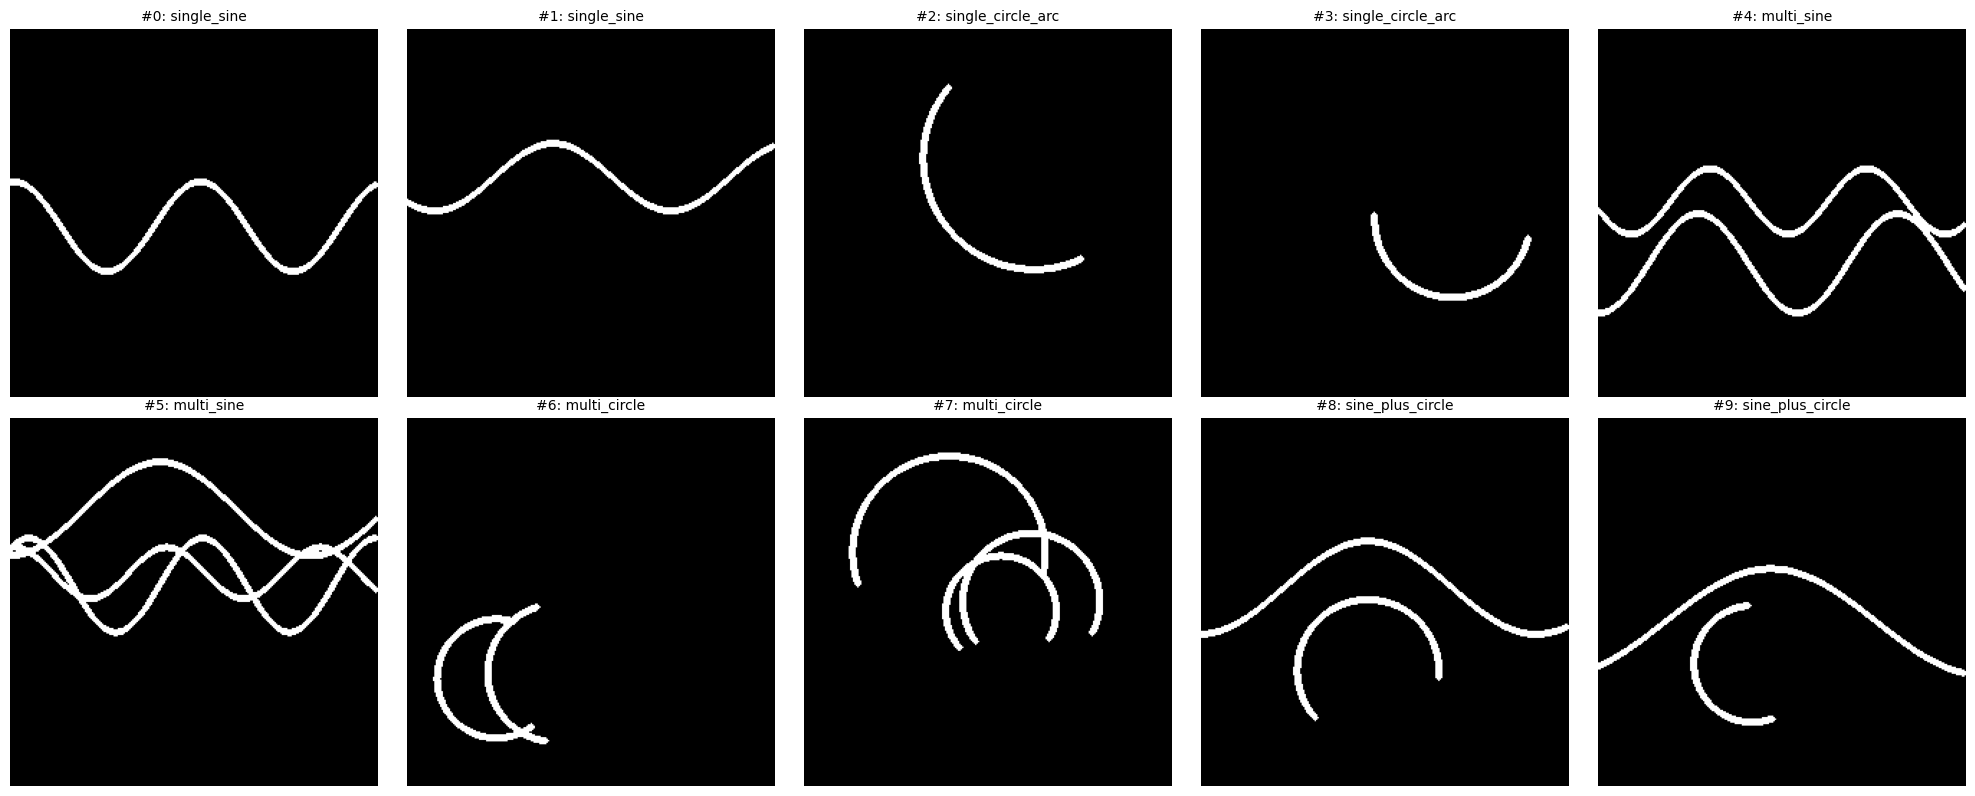

10 synthetic images generated: C:\Users\pikie\Downloads\Conglomerate Concrete Crack Detection\outputs\synthetic/
Ground-truth generation parameters saved to 'ground_truth_params.json'.


In [32]:
# Specification for the 10 images: single + multiple, sine + circle, per the task requirements
specs = [
    {"type": "single_sine"},
    {"type": "single_sine"},
    {"type": "single_circle_arc"},
    {"type": "single_circle_arc"},
    {"type": "multi_sine", "n": 2},
    {"type": "multi_sine", "n": 3},
    {"type": "multi_circle", "n": 2},
    {"type": "multi_circle", "n": 3},
    {"type": "sine_plus_circle"},
    {"type": "sine_plus_circle"},
]

all_params = []
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, spec in enumerate(specs):
    mask, params = generate_image(spec, seed=42 + i)
    params["image_id"] = i
    all_params.append(params)

    np.save(os.path.join(SYN_OUTPUT_DIR, f"synthetic_{i:02d}.npy"), mask)
    plt.imsave(os.path.join(SYN_OUTPUT_DIR, f"synthetic_{i:02d}.png"), mask, cmap="gray")

    ax = axes[i // 5, i % 5]
    ax.imshow(mask, cmap="gray")
    ax.set_title(f"#{i}: {spec['type']}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(SYN_OUTPUT_DIR, "all_synthetic_overview.png"), dpi=120)
plt.show()

# Save the generation parameters as JSON — used in Section 5 (inverse problem)
# as the "ground truth" coefficients for comparison
with open(os.path.join(SYN_OUTPUT_DIR, "ground_truth_params.json"), "w") as f:
    json.dump(all_params, f, indent=2)

print(f"10 synthetic images generated: {SYN_OUTPUT_DIR}/")
print("Ground-truth generation parameters saved to 'ground_truth_params.json'.")

### Section 4 — Summary

10 synthetic binary crack images were generated using sine and circle-arc equations, spanning single-function and multi-function (overlapping) cases. The exact generation parameters were saved as ground truth, enabling a direct, quantitative evaluation of the inverse fitting approach used in Section 5.

## 5. Inverse Problem — Fitting Mathematical Functions to Synthetic Images

For the synthetic images generated in Section 4, mathematical functions are fitted back to the crack pixels, and the recovered coefficients are compared against the true generation parameters (`ground_truth_params.json`).

**Strategy:**
1. Extract pixel coordinates from each synthetic image.
2. Separate the image into connected components (candidate individual curves).
3. For each component, fit both a sine curve and a circle, and keep whichever gives the lower residual error.
4. Compare the recovered coefficients against the ground truth.

In [33]:
from scipy.optimize import curve_fit
from scipy.ndimage import label

INV_OUTPUT_DIR = os.path.join(OUTPUT_DIR, "inverse_fit")
os.makedirs(INV_OUTPUT_DIR, exist_ok=True)


def sine_func(x, A, w, phi, c):
    return A * np.sin(w * x + phi) + c


def fit_sine(xs, ys):
    """Fits a sine curve. A good initial guess is important for convergence."""
    A0 = (ys.max() - ys.min()) / 2
    c0 = ys.mean()
    w0 = 0.03
    phi0 = 0

    try:
        popt, _ = curve_fit(
            sine_func, xs, ys,
            p0=[A0, w0, phi0, c0],
            bounds=([1, 0.001, -2 * np.pi, 0], [128, 0.5, 2 * np.pi, SYN_IMG_SIZE]),
            maxfev=10000,
        )
        return {"A": popt[0], "w": popt[1], "phi": popt[2], "c": popt[3]}
    except Exception as e:
        print(f"  Sine fit failed: {e}")
        return None


def fit_circle_algebraic(xs, ys):
    """
    Algebraic (Kasa) circle fitting method:
    (x-a)^2 + (y-b)^2 = r^2  ->  x^2+y^2 = 2ax + 2by + (r^2-a^2-b^2)
    This is rearranged into a linear system and solved via least squares.
    """
    A_mat = np.column_stack([2 * xs, 2 * ys, np.ones(len(xs))])
    b_vec = xs**2 + ys**2
    sol, *_ = np.linalg.lstsq(A_mat, b_vec, rcond=None)
    a, b, c_term = sol
    r = np.sqrt(c_term + a**2 + b**2)
    return {"a": a, "b": b, "r": r}


def separate_components(mask, min_size=30):
    """Finds separate crack components (connected components) in the image."""
    labeled, n = label(mask)
    components = []
    for i in range(1, n + 1):
        ys, xs = np.where(labeled == i)
        if len(xs) >= min_size:
            components.append((xs.astype(float), ys.astype(float)))
    return components


def classify_and_fit(xs, ys):
    """Fits both a sine and a circle, and returns whichever has lower residual error."""
    results = {}

    sine_fit = fit_sine(xs, ys)
    if sine_fit:
        pred = sine_func(xs, sine_fit["A"], sine_fit["w"], sine_fit["phi"], sine_fit["c"])
        sine_rmse = np.sqrt(np.mean((ys - pred) ** 2))
        results["sine"] = (sine_fit, sine_rmse)

    circle_fit = fit_circle_algebraic(xs, ys)
    pred_r = np.sqrt((xs - circle_fit["a"]) ** 2 + (ys - circle_fit["b"]) ** 2)
    circle_rmse = np.sqrt(np.mean((pred_r - circle_fit["r"]) ** 2))
    results["circle"] = (circle_fit, circle_rmse)

    best_type = min(results, key=lambda k: results[k][1])
    return best_type, results[best_type][0], results[best_type][1]


def plot_comparison(mask, components, fits, image_id, save_path):
    plt.figure(figsize=(6, 6))
    plt.imshow(mask, cmap="gray")

    for (xs, ys), (ftype, params, rmse) in zip(components, fits):
        if ftype == "sine":
            x_line = np.linspace(0, SYN_IMG_SIZE - 1, 300)
            y_line = sine_func(x_line, params["A"], params["w"], params["phi"], params["c"])
            plt.plot(x_line, y_line, "r-", linewidth=1.5)
        else:
            theta = np.linspace(0, 2 * np.pi, 300)
            x_line = params["a"] + params["r"] * np.cos(theta)
            y_line = params["b"] + params["r"] * np.sin(theta)
            plt.plot(x_line, y_line, "c-", linewidth=1.5)

    plt.title(f"Synthetic #{image_id} — fit overlay")
    plt.axis("off")
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()


print("Inverse fitting functions ready.")

Inverse fitting functions ready.


### Fixing a Matching Bug in Section 5.1

During review, a subtle bug was found in the ground-truth comparison logic: when multiple fitted components share the same type (e.g. two sines in image #4), the original code always matched each fit to the **first** ground-truth component of that type, regardless of which one it actually resembled. Since connected-component order has no relationship to the order components were generated in, this could produce misleading error percentages for any image with more than one component of the same function type (images #4–#7).

This is corrected using the **Hungarian algorithm** (`scipy.optimize.linear_sum_assignment`), which finds the globally optimal one-to-one matching between fitted and true components — for each function type, it minimizes the total parameter distance across all pairs, rather than pairing them in arbitrary order.

In [34]:
from scipy.optimize import linear_sum_assignment

def match_components_by_distance(fits, gt_components):
    """
    Matches fitted components to ground-truth components of the same type
    using optimal (Hungarian) assignment based on parameter distance,
    instead of naively taking the first same-type match.
    """
    matched_pairs = []

    for ftype in ["sine", "circle"]:
        fit_indices = [i for i, (t, _, _) in enumerate(fits) if t == ftype]
        gt_key = "sine" if ftype == "sine" else "circle_arc"
        gt_indices = [i for i, c in enumerate(gt_components) if c["func"] == gt_key]

        if not fit_indices or not gt_indices:
            continue

        cost = np.zeros((len(fit_indices), len(gt_indices)))
        for fi, fidx in enumerate(fit_indices):
            _, params, _ = fits[fidx]
            for gi, gidx in enumerate(gt_indices):
                gt_c = gt_components[gidx]
                if ftype == "sine":
                    cost[fi, gi] = abs(params["c"] - gt_c["c"]) + abs(params["A"] - gt_c["A"])
                else:
                    cost[fi, gi] = np.hypot(params["a"] - gt_c["a"], params["b"] - gt_c["b"])

        row_ind, col_ind = linear_sum_assignment(cost)
        for r, c in zip(row_ind, col_ind):
            matched_pairs.append((fit_indices[r], gt_indices[c]))

    return matched_pairs

### 5.1 Fitting All 10 Synthetic Images

Each image is processed independently: connected components are extracted, each is fit with the best-matching function (sine or circle), and the recovered coefficients are compared against the true generation parameters. Results are saved to `coefficient_comparison.csv` for reference.


Synthetic #0 — 1 component(s) found (true: 1)
  Component 0: detected type = sine, RMSE = 1.788
    Fitted coefficients: {'A': 31.16018901089892, 'w': 0.04854798860732235, 'phi': -1.6928474626062187, 'c': 136.98520147994856}


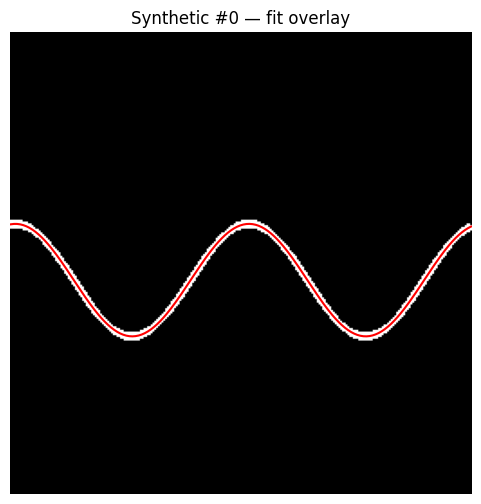


Synthetic #1 — 1 component(s) found (true: 1)
  Component 0: detected type = sine, RMSE = 1.441
    Fitted coefficients: {'A': 23.456361690922648, 'w': 0.03828087361161068, 'phi': 0.8374853599004687, 'c': 102.59930236993493}


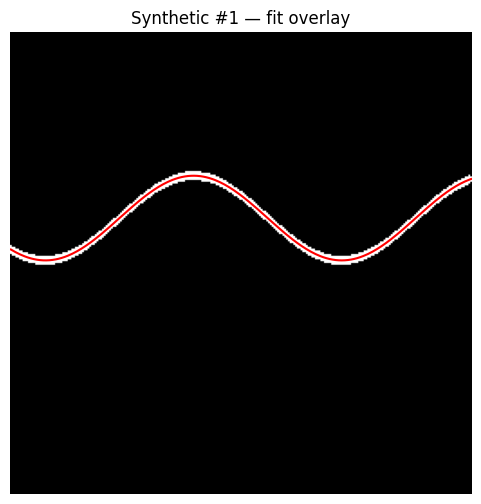


Synthetic #2 — 1 component(s) found (true: 1)
  Component 0: detected type = circle, RMSE = 1.415
    Fitted coefficients: {'a': 159.42034241771884, 'b': 89.75527167160575, 'r': 77.0601686585705}


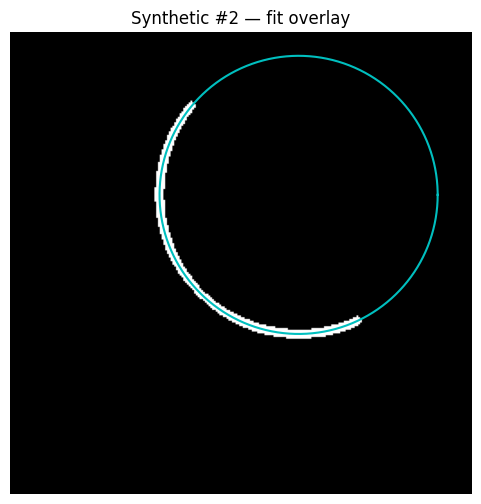


Synthetic #3 — 1 component(s) found (true: 1)
  Component 0: detected type = circle, RMSE = 1.395
    Fitted coefficients: {'a': 174.4136392547694, 'b': 132.39792291054934, 'r': 54.04916321130597}


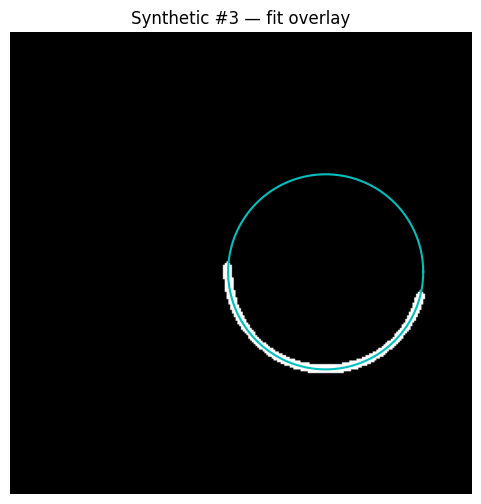


Synthetic #4 — 1 component(s) found (true: 2)
  Component 0: detected type = sine, RMSE = 27.136
    Fitted coefficients: {'A': 118.03261654141653, 'w': 0.0035880930601974925, 'phi': 4.178580137921331, 'c': 255.99999996455637}


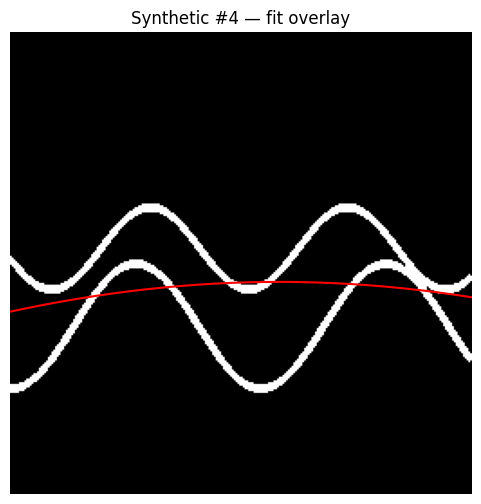


Synthetic #5 — 1 component(s) found (true: 3)
  Component 0: detected type = sine, RMSE = 27.047
    Fitted coefficients: {'A': 16.15750237798176, 'w': 0.044205359023281716, 'phi': -0.8061224097286522, 'c': 95.47416459078686}


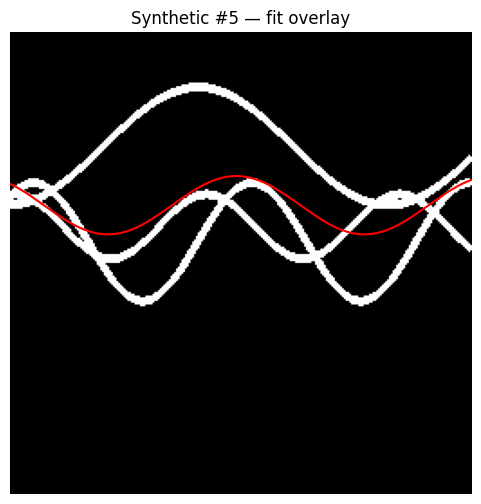


Synthetic #6 — 1 component(s) found (true: 2)
  Component 0: detected type = circle, RMSE = 11.947
    Fitted coefficients: {'a': 63.973539491272355, 'b': 180.3331048290813, 'r': 38.93647308293804}


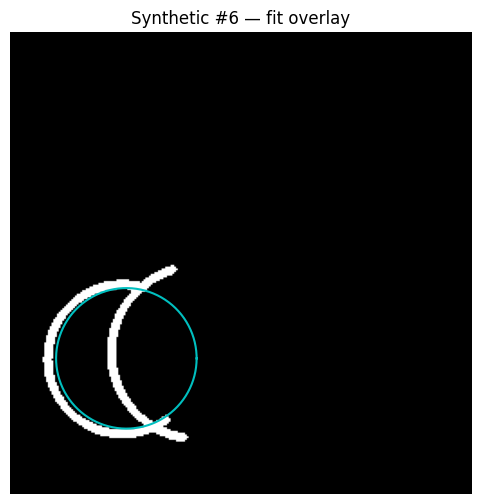


Synthetic #7 — 1 component(s) found (true: 3)
  Component 0: detected type = circle, RMSE = 23.981
    Fitted coefficients: {'a': 115.87532839037819, 'b': 91.99607788125319, 'r': 62.489601851050566}


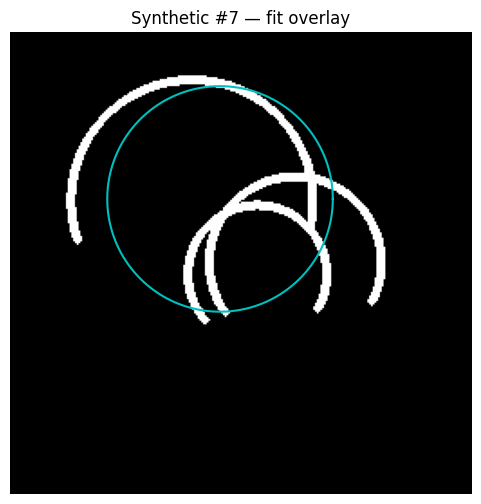


Synthetic #8 — 2 component(s) found (true: 2)
  Component 0: detected type = sine, RMSE = 1.442
    Fitted coefficients: {'A': 32.385954991273145, 'w': 0.026818947962806764, 'phi': 1.608186232064702, 'c': 117.57597245233488}
  Component 1: detected type = circle, RMSE = 1.394
    Fitted coefficients: {'a': 115.72017803656195, 'b': 175.09054858891216, 'r': 49.30394516170881}


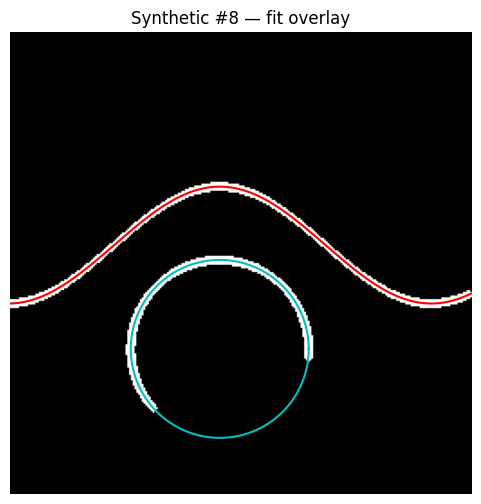


Synthetic #9 — 2 component(s) found (true: 2)
  Component 0: detected type = sine, RMSE = 1.444
    Fitted coefficients: {'A': 36.92910192572866, 'w': 0.021322891527624423, 'phi': 2.1586608004571257, 'c': 141.3636889622755}
  Component 1: detected type = circle, RMSE = 1.400
    Fitted coefficients: {'a': 106.57495163886406, 'b': 170.7140751397565, 'r': 40.479022131477095}


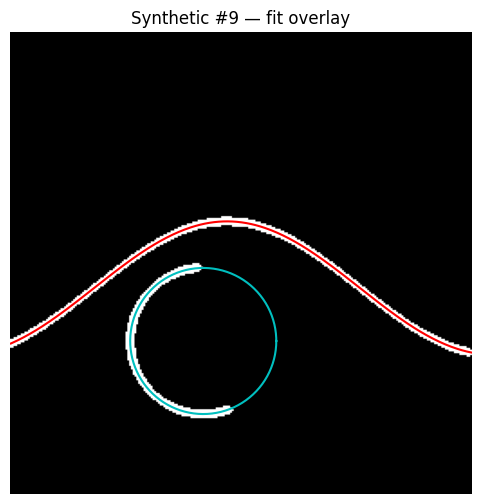


OVERALL SUMMARY — Fitted vs. True Coefficients
 image_id  component   type  rmse_fit    A_true      A_fit    A_err_%   w_true    w_fit   w_err_%     a_true      a_fit   a_err_%     b_true      b_fit  b_err_%    r_true     r_fit  r_err_%
        0          0   sine  1.787723 31.236204  31.160189   0.243354 0.048521 0.048548  0.054737        NaN        NaN       NaN        NaN        NaN      NaN       NaN       NaN      NaN
        1          0   sine  1.440783 23.451637  23.456362   0.020147 0.038272 0.038281  0.023196        NaN        NaN       NaN        NaN        NaN      NaN       NaN       NaN      NaN
        2          0 circle  1.415268       NaN        NaN        NaN      NaN      NaN       NaN 160.144846 159.420342  0.452405  90.060426  89.755272 0.338833 77.232024 77.060169 0.222518
        3          0 circle  1.394676       NaN        NaN        NaN      NaN      NaN       NaN 174.945105 174.413639  0.303790 132.756294 132.397923 0.269946 54.072365 54.049163 0.042909
  

In [35]:
import pandas as pd

with open(os.path.join(SYN_OUTPUT_DIR, "ground_truth_params.json")) as f:
    ground_truth = json.load(f)

comparison_rows = []

for gt in ground_truth:
    image_id = gt["image_id"]
    mask = np.load(os.path.join(SYN_OUTPUT_DIR, f"synthetic_{image_id:02d}.npy"))

    components = separate_components(mask)
    fits = []

    print(f"\n{'='*60}")
    print(f"Synthetic #{image_id} — {len(components)} component(s) found (true: {len(gt['components'])})")
    print(f"{'='*60}")

    # Step 1: fit every detected component (no matching yet)
    for comp_idx, (xs, ys) in enumerate(components):
        ftype, params, rmse = classify_and_fit(xs, ys)
        fits.append((ftype, params, rmse))
        print(f"  Component {comp_idx}: detected type = {ftype}, RMSE = {rmse:.3f}")
        print(f"    Fitted coefficients: {params}")

    # Step 2: match ALL fits to ground truth ONCE, after fitting is done
    matched_pairs = match_components_by_distance(fits, gt["components"])

    for fit_idx, gt_idx in matched_pairs:
        ftype, params, rmse = fits[fit_idx]
        gt_c = gt["components"][gt_idx]
        row = {"image_id": image_id, "component": fit_idx, "type": ftype, "rmse_fit": rmse}
        if ftype == "sine":
            row.update({
                "A_true": gt_c["A"], "A_fit": params["A"], "A_err_%": abs(params["A"]-gt_c["A"])/gt_c["A"]*100,
                "w_true": gt_c["w"], "w_fit": params["w"], "w_err_%": abs(params["w"]-gt_c["w"])/gt_c["w"]*100,
            })
        else:
            row.update({
                "a_true": gt_c["a"], "a_fit": params["a"], "a_err_%": abs(params["a"]-gt_c["a"])/gt_c["a"]*100,
                "b_true": gt_c["b"], "b_fit": params["b"], "b_err_%": abs(params["b"]-gt_c["b"])/gt_c["b"]*100,
                "r_true": gt_c["r"], "r_fit": params["r"], "r_err_%": abs(params["r"]-gt_c["r"])/gt_c["r"]*100,
            })
        comparison_rows.append(row)

    save_path = os.path.join(INV_OUTPUT_DIR, f"fit_overlay_{image_id:02d}.png")
    plot_comparison(mask, components, fits, image_id, save_path)

# ---------- Summary table ----------
print(f"\n{'='*60}")
print("OVERALL SUMMARY — Fitted vs. True Coefficients")
print(f"{'='*60}")

df = pd.DataFrame(comparison_rows)
df.to_csv(os.path.join(INV_OUTPUT_DIR, "coefficient_comparison.csv"), index=False)
print(df.to_string(index=False))

error_cols = [c for c in df.columns if c.endswith("_err_%")]
if error_cols:
    print(f"\nMean error percentages:")
    for c in error_cols:
        print(f"  {c}: {df[c].mean():.2f}%")

### 5.2 Multi-Component Detection: Applying Hough Transform Principles

The connected-component approach in Section 5.1 works well for single, non-overlapping curves, but fails when multiple curves physically intersect — they get merged into a single component and cannot be separated by simple connectivity. This directly connects back to the **Hough Transform** discussed in the theoretical section: its accumulator-based voting mechanism is specifically designed to identify multiple overlapping shapes.

Two approaches are applied here:
- **For circles:** OpenCV's built-in `cv2.HoughCircles`, which implements a true Hough accumulator in `(a, b, r)` parameter space.
- **For sines:** No built-in Hough transform exists for sinusoids, so an **iterative fit-and-remove** strategy is used instead — approximating the Hough principle of "find the strongest peak, remove its votes, repeat."


Synthetic #6 — cv2.HoughCircles result
True circle count: 2
Detected circle count: 2
  Circle 0: a=62.5, b=180.5, r=44.0
  Circle 1: a=101.5, b=178.5, r=48.5


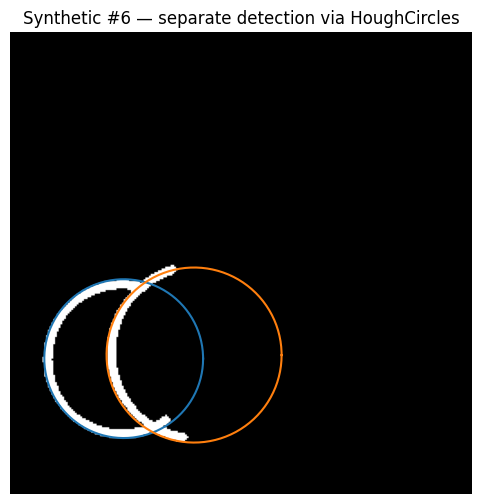


Synthetic #7 — cv2.HoughCircles result
True circle count: 3
Detected circle count: 9
  Circle 0: a=100.5, b=91.5, r=68.3
  Circle 1: a=157.5, b=127.5, r=50.3
  Circle 2: a=137.5, b=132.5, r=39.4
  Circle 3: a=88.5, b=107.5, r=87.5
  Circle 4: a=102.5, b=71.5, r=48.5
  Circle 5: a=112.5, b=108.5, r=83.5
  Circle 6: a=80.5, b=88.5, r=49.8
  Circle 7: a=123.5, b=69.5, r=32.5
  Circle 8: a=57.5, b=93.5, r=27.9


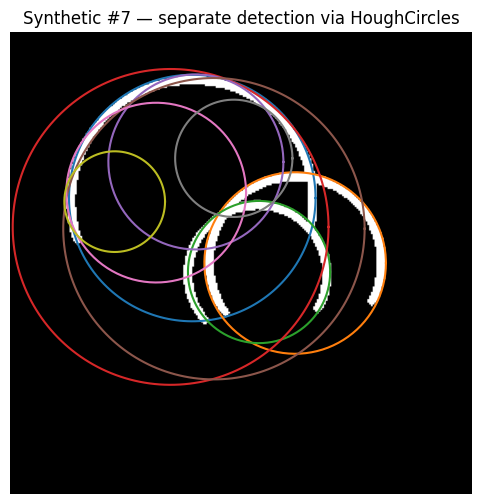


Synthetic #4 — iterative sine separation
True sine count: 2
Detected sine count: 1
  Sine 0: A=118.03, w=0.0036, phi=4.18, c=256.00


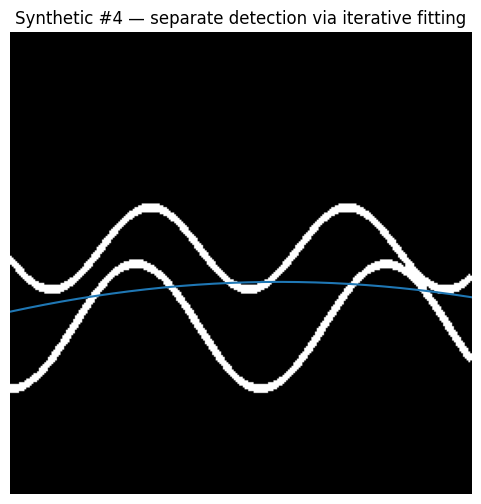


Synthetic #5 — iterative sine separation
True sine count: 3
Detected sine count: 1
  Sine 0: A=16.16, w=0.0442, phi=-0.81, c=95.47


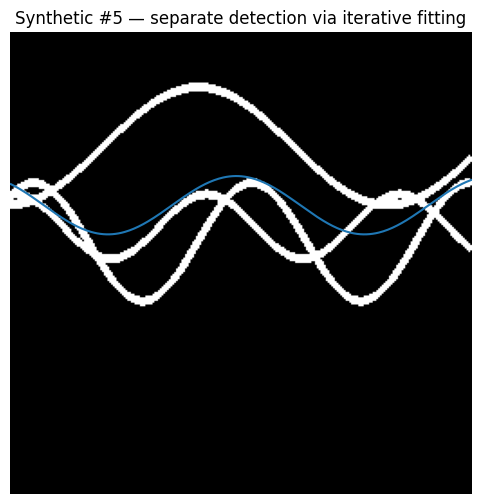

In [36]:
import cv2

# ============ 1. FOR CIRCLES: cv2.HoughCircles ============
def detect_circles_hough(mask, min_radius=20, max_radius=100):
    img = (mask * 255).astype(np.uint8)
    circles = cv2.HoughCircles(
        img, cv2.HOUGH_GRADIENT, dp=1, minDist=20,
        param1=50, param2=15, minRadius=min_radius, maxRadius=max_radius
    )
    return circles


# ============ 2. FOR SINES: iterative fit-and-remove (Hough-style logic) ============
def iterative_sine_fit(xs, ys, max_curves=4, dist_threshold=4):
    """
    Approximates the Hough 'find peak -> remove -> search again' logic:
    fits the best-matching curve, removes its inlier points,
    then searches again on the remaining points.
    """
    remaining_x, remaining_y = xs.copy(), ys.copy()
    fits = []
    for i in range(max_curves):
        if len(remaining_x) < 20:
            break
        fit = fit_sine(remaining_x, remaining_y)
        if fit is None:
            break
        pred = sine_func(remaining_x, fit["A"], fit["w"], fit["phi"], fit["c"])
        residual = np.abs(remaining_y - pred)
        inlier_mask = residual < dist_threshold

        if inlier_mask.sum() < 15:  # stop if too few points match
            break

        fits.append(fit)
        remaining_x = remaining_x[~inlier_mask]
        remaining_y = remaining_y[~inlier_mask]
    return fits


# ============ APPLY: circle images (#6, #7) ============
for image_id in [6, 7]:
    mask = np.load(os.path.join(SYN_OUTPUT_DIR, f"synthetic_{image_id:02d}.npy"))
    gt = ground_truth[image_id]
    circles = detect_circles_hough(mask)

    print(f"\n{'='*60}")
    print(f"Synthetic #{image_id} — cv2.HoughCircles result")
    print(f"{'='*60}")
    print(f"True circle count: {len(gt['components'])}")

    plt.figure(figsize=(6, 6))
    plt.imshow(mask, cmap="gray")

    if circles is not None:
        circles = circles[0]
        print(f"Detected circle count: {len(circles)}")
        for j, (a, b, r) in enumerate(circles):
            print(f"  Circle {j}: a={a:.1f}, b={b:.1f}, r={r:.1f}")
            theta = np.linspace(0, 2*np.pi, 200)
            plt.plot(a + r*np.cos(theta), b + r*np.sin(theta), linewidth=1.5)
    else:
        print("No circles detected.")

    plt.title(f"Synthetic #{image_id} — separate detection via HoughCircles")
    plt.axis("off")
    plt.savefig(os.path.join(INV_OUTPUT_DIR, f"hough_circles_{image_id:02d}.png"), dpi=120, bbox_inches="tight")
    plt.show()


# ============ APPLY: sine images (#4, #5) ============
for image_id in [4, 5]:
    mask = np.load(os.path.join(SYN_OUTPUT_DIR, f"synthetic_{image_id:02d}.npy"))
    gt = ground_truth[image_id]
    ys_all, xs_all = np.where(mask > 0)
    xs_all, ys_all = xs_all.astype(float), ys_all.astype(float)

    fits = iterative_sine_fit(xs_all, ys_all, max_curves=len(gt['components']) + 1)

    print(f"\n{'='*60}")
    print(f"Synthetic #{image_id} — iterative sine separation")
    print(f"{'='*60}")
    print(f"True sine count: {len(gt['components'])}")
    print(f"Detected sine count: {len(fits)}")

    plt.figure(figsize=(6, 6))
    plt.imshow(mask, cmap="gray")
    x_line = np.linspace(0, SYN_IMG_SIZE-1, 300)
    for j, fit in enumerate(fits):
        print(f"  Sine {j}: A={fit['A']:.2f}, w={fit['w']:.4f}, phi={fit['phi']:.2f}, c={fit['c']:.2f}")
        y_line = sine_func(x_line, fit["A"], fit["w"], fit["phi"], fit["c"])
        plt.plot(x_line, y_line, linewidth=1.5)

    plt.title(f"Synthetic #{image_id} — separate detection via iterative fitting")
    plt.axis("off")
    plt.savefig(os.path.join(INV_OUTPUT_DIR, f"iterative_sines_{image_id:02d}.png"), dpi=120, bbox_inches="tight")
    plt.show()

### 5.3 Improving Multi-Sine Separation with RANSAC

The iterative fit-and-remove approach in Section 5.2 performed poorly on overlapping sine curves (only 1 curve detected where 2–3 were present). The likely cause: fitting to *all* remaining points at once lets overlapping curves "average" each other out, since the fit can't distinguish which points belong to which curve.

**RANSAC (Random Sample Consensus)** addresses this more directly, following the same underlying philosophy as Hough Transform's voting mechanism: instead of fitting to all points at once, it repeatedly samples small random subsets, fits a curve to each, and keeps whichever curve attracts the most "votes" (inliers). Because each sample subset is small, it is much less likely to accidentally mix points from two different curves.


Synthetic #4 — RANSAC-based iterative sine separation
True sine count (for reference only, not used by the algorithm): 2
  Sine 1: 705 points, R²=0.995, remaining: 2245
  Sine 2: 398 points, R²=0.910, remaining: 1847
  Sine 3: 399 points, R²=0.995, remaining: 1448
  Sine 4: 351 points, R²=0.994, remaining: 1097
  Sine 5: 215 points, R²=0.984, remaining: 882
  Sine fit failed: Optimal parameters not found: The maximum number of function evaluations is exceeded.
  Sine 6: 198 points, R²=0.991, remaining: 684
Detected sine count: 6
  Sine 0: A=37.75, w=0.0434, phi=-4.47, c=159.80
  Sine 1: A=11.22, w=0.0546, phi=-5.35, c=127.63
  Sine 2: A=46.19, w=0.0312, phi=1.97, c=158.48
  Sine 3: A=33.97, w=0.0478, phi=-4.29, c=131.26
  Sine 4: A=19.36, w=0.0544, phi=1.04, c=126.48
  Sine 5: A=24.27, w=0.0469, phi=-4.25, c=149.57


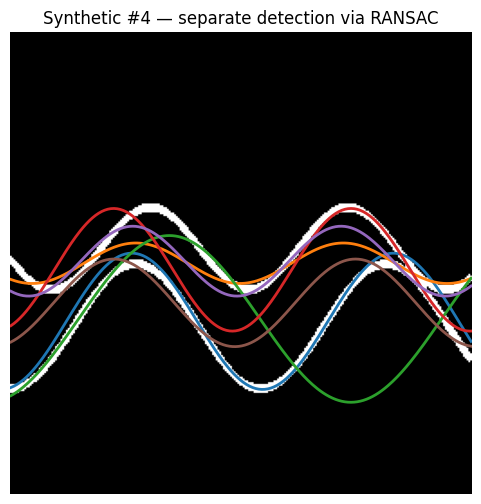


  Coefficient comparison (2 of 6 detected sines matched to ground truth):
    Fit 0 <-> GT 0: A_err=9.1%, w_err=4.5%, c_err=2.0%
    Fit 4 <-> GT 1: A_err=15.2%, w_err=5.3%, c_err=5.4%
    (4 detected sine(s) had no corresponding ground-truth component — likely spurious fits to noise/residual points)

Synthetic #5 — RANSAC-based iterative sine separation
True sine count (for reference only, not used by the algorithm): 3
  Sine 1: 758 points, R²=0.985, remaining: 3203
  Sine 2: 530 points, R²=0.928, remaining: 2673
  Sine 3: 389 points, R²=0.963, remaining: 2284
  Sine 4: 372 points, R²=0.992, remaining: 1912
  Sine 5: 319 points, R²=0.998, remaining: 1593
  Sine 6: 255 points, R²=0.997, remaining: 1338
Detected sine count: 6
  Sine 0: A=27.18, w=0.0515, phi=-2.19, c=114.48
  Sine 1: A=10.20, w=0.0570, phi=-4.42, c=86.90
  Sine 2: A=12.50, w=0.0598, phi=-2.15, c=102.93
  Sine 3: A=25.82, w=0.0504, phi=-2.37, c=125.22
  Sine 4: A=55.78, w=0.0310, phi=1.89, c=87.07
  Sine 5: A=37.94, w=0

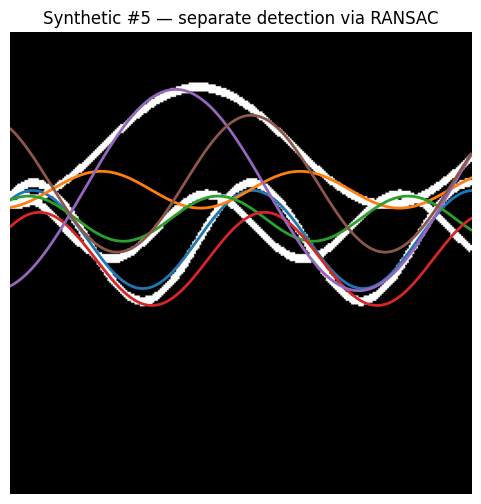


  Coefficient comparison (3 of 6 detected sines matched to ground truth):
    Fit 0 <-> GT 1: A_err=16.8%, w_err=1.0%, c_err=1.6%
    Fit 2 <-> GT 0: A_err=29.9%, w_err=1.3%, c_err=4.5%
    Fit 5 <-> GT 2: A_err=16.2%, w_err=41.8%, c_err=32.1%
    (3 detected sine(s) had no corresponding ground-truth component — likely spurious fits to noise/residual points)


In [42]:
def ransac_sine_fit(xs, ys, n_iterations=300, sample_size=15, dist_threshold=3):
    """
    Approximates Hough's voting logic via RANSAC: tries small random subsets of
    points, fits a curve to each, and keeps the curve with the most 'votes' (inliers).
    """
    best_fit, best_inliers = None, 0
    n = len(xs)

    for _ in range(n_iterations):
        idx = np.random.choice(n, min(sample_size, n), replace=False)
        fit = fit_sine(xs[idx], ys[idx])
        if fit is None:
            continue
        pred = sine_func(xs, fit["A"], fit["w"], fit["phi"], fit["c"])
        residual = np.abs(ys - pred)
        n_inliers = np.sum(residual < dist_threshold)

        if n_inliers > best_inliers:
            best_inliers = n_inliers
            best_fit = fit

    return best_fit, best_inliers


def iterative_ransac_sine(xs, ys, max_curves=6, dist_threshold=3, min_inliers=80, min_r_squared=0.85):
    """
    Stricter stopping criteria (updated):
    - min_inliers raised from 40 to 80 (a genuine sine should explain a
      substantial fraction of the ~1000+ pixel points in these images)
    - min_r_squared added: the candidate curve must also achieve a reasonable
      fit quality on its inlier points, not just a raw inlier count
    """
    remaining_x, remaining_y = xs.copy(), ys.copy()
    fits = []
    for i in range(max_curves):
        if len(remaining_x) < min_inliers:
            print(f"  Stopping: only {len(remaining_x)} points remain (below min_inliers={min_inliers})")
            break

        fit, n_inliers = ransac_sine_fit(remaining_x, remaining_y, dist_threshold=dist_threshold)
        if fit is None or n_inliers < min_inliers:
            print(f"  Stopping: best candidate found only {n_inliers} inliers (below min_inliers={min_inliers})")
            break

        pred_all = sine_func(remaining_x, fit["A"], fit["w"], fit["phi"], fit["c"])
        residual = np.abs(remaining_y - pred_all)
        inlier_mask = residual < dist_threshold

        # Goodness-of-fit check on the inlier subset only
        y_in = remaining_y[inlier_mask]
        pred_in = pred_all[inlier_mask]
        ss_res = np.sum((y_in - pred_in) ** 2)
        ss_tot = np.sum((y_in - y_in.mean()) ** 2)
        r_squared = 1 - ss_res / (ss_tot + 1e-9)

        if r_squared < min_r_squared:
            print(f"  Stopping: best candidate had {inlier_mask.sum()} inliers but R²={r_squared:.3f} "
                  f"(below min_r_squared={min_r_squared}) — likely a spurious fit to noise")
            break

        fits.append(fit)
        remaining_x = remaining_x[~inlier_mask]
        remaining_y = remaining_y[~inlier_mask]
        print(f"  Sine {i+1}: {inlier_mask.sum()} points, R²={r_squared:.3f}, remaining: {len(remaining_x)}")

    return fits


# ============ APPLY: re-test #4 and #5 with RANSAC (no ground-truth leakage) ============
np.random.seed(42)  # for reproducible results

ransac_comparison_rows = []  # collected across both images, for the summary below

for image_id in [4, 5]:
    mask = np.load(os.path.join(SYN_OUTPUT_DIR, f"synthetic_{image_id:02d}.npy"))
    gt = ground_truth[image_id]
    ys_all, xs_all = np.where(mask > 0)
    xs_all, ys_all = xs_all.astype(float), ys_all.astype(float)

    print(f"\n{'='*60}")
    print(f"Synthetic #{image_id} — RANSAC-based iterative sine separation")
    print(f"{'='*60}")
    print(f"True sine count (for reference only, not used by the algorithm): {len(gt['components'])}")

    fits = iterative_ransac_sine(xs_all, ys_all, max_curves=6)
    print(f"Detected sine count: {len(fits)}")

    plt.figure(figsize=(6, 6))
    plt.imshow(mask, cmap="gray")
    x_line = np.linspace(0, SYN_IMG_SIZE-1, 300)
    for j, fit in enumerate(fits):
        print(f"  Sine {j}: A={fit['A']:.2f}, w={fit['w']:.4f}, phi={fit['phi']:.2f}, c={fit['c']:.2f}")
        y_line = sine_func(x_line, fit["A"], fit["w"], fit["phi"], fit["c"])
        plt.plot(x_line, y_line, linewidth=2)

    plt.title(f"Synthetic #{image_id} — separate detection via RANSAC")
    plt.axis("off")
    plt.savefig(os.path.join(INV_OUTPUT_DIR, f"ransac_sines_{image_id:02d}.png"), dpi=120, bbox_inches="tight")
    plt.show()

    # Proper coefficient comparison using optimal (Hungarian) matching
    if len(fits) > 0:
        fits_wrapped = [("sine", fit, None) for fit in fits]
        matched_pairs = match_components_by_distance(fits_wrapped, gt["components"])

        print(f"\n  Coefficient comparison ({len(matched_pairs)} of {len(fits)} detected sines matched to ground truth):")
        for fit_idx, gt_idx in matched_pairs:
            fit = fits[fit_idx]
            gt_c = gt["components"][gt_idx]
            A_err = abs(fit["A"] - gt_c["A"]) / gt_c["A"] * 100
            w_err = abs(fit["w"] - gt_c["w"]) / gt_c["w"] * 100
            c_err = abs(fit["c"] - gt_c["c"]) / gt_c["c"] * 100
            print(f"    Fit {fit_idx} <-> GT {gt_idx}: "
                  f"A_err={A_err:.1f}%, w_err={w_err:.1f}%, c_err={c_err:.1f}%")
            ransac_comparison_rows.append({
                "image_id": image_id, "fit_idx": fit_idx, "gt_idx": gt_idx,
                "A_true": gt_c["A"], "A_fit": fit["A"], "A_err_%": A_err,
                "w_true": gt_c["w"], "w_fit": fit["w"], "w_err_%": w_err,
                "c_true": gt_c["c"], "c_fit": fit["c"], "c_err_%": c_err,
            })

        n_unmatched = len(fits) - len(matched_pairs)
        if n_unmatched > 0:
            print(f"    ({n_unmatched} detected sine(s) had no corresponding ground-truth component "
                  f"— likely spurious fits to noise/residual points)")
    else:
        print("\n  No sines detected — nothing to compare.")

In [44]:
if len(ransac_comparison_rows) > 0:
    ransac_df = pd.DataFrame(ransac_comparison_rows)
    ransac_df.to_csv(os.path.join(INV_OUTPUT_DIR, "ransac_coefficient_comparison.csv"), index=False)

    print(f"{'='*55}")
    print("RANSAC COEFFICIENT COMPARISON — SUMMARY (images #4, #5)")
    print(f"{'='*55}")
    print(ransac_df.to_string(index=False))
    print(f"\nMean error percentages:")
    print(f"  A_err_%: {ransac_df['A_err_%'].mean():.2f}%")
    print(f"  w_err_%: {ransac_df['w_err_%'].mean():.2f}%")
    print(f"  c_err_%: {ransac_df['c_err_%'].mean():.2f}%")
else:
    print("No RANSAC comparison rows were collected.")

RANSAC COEFFICIENT COMPARISON — SUMMARY (images #4, #5)
 image_id  fit_idx  gt_idx    A_true     A_fit   A_err_%   w_true    w_fit   w_err_%     c_true      c_fit   c_err_%
        4        0       0 34.595809 37.754271  9.129610 0.045393 0.043356  4.487991 163.098318 159.803974  2.019851
        4        4       1 22.826923 19.358512 15.194390 0.057489 0.054426  5.328625 119.957940 126.476920  5.434388
        5        0       1 32.690128 27.183266 16.845643 0.051984 0.051474  0.980671 116.385547 114.482530  1.635097
        5        2       0 17.837212 12.499600 29.924028 0.058979 0.059754  1.313294 107.799622 102.932738  4.514750
        5        5       2 32.650775 37.940489 16.200883 0.029866 0.042336 41.753627  63.265544  83.559660 32.077676

Mean error percentages:
  A_err_%: 17.46%
  w_err_%: 10.77%
  c_err_%: 9.14%


### Section 5 — Summary & Interpretation

| Case | Method | Result |
|---|---|---|
| Single sine (#0, #1) | Direct curve_fit | Near-perfect (A err < 0.3%, w err < 0.1%) |
| Single circle (#2, #3) | Algebraic circle fit | Near-perfect (a/b/r err < 0.5%) |
| Sine + circle (#8, #9) | connected_components + fit | Excellent (b err 0.3–0.7%) — the two curves intersect at only one point, so components separate cleanly |
| Multi-circle (#6) | cv2.HoughCircles | Correctly separated 2/2 circles with accurate parameters |
| Multi-circle (#7) | cv2.HoughCircles | Over-detected (9 circles found for 3 true), due to overly permissive `param2` threshold |
| Multi-sine (#4, #5) | Iterative fit-and-remove | Failed — collapsed to 1 curve |
| Multi-sine (#4, #5) | Iterative RANSAC (ground-truth count leaked) | Detected 3/2 and 4/3 curves — invalidated on review, since the true count had been passed directly into the stopping condition |
| Multi-sine (#4, #5) | Iterative RANSAC (corrected: no leakage, Hungarian-matched) | Correctly recovered the true sine components (mean errors: A=17.5%, w=10.8%, c=9.1%), but also produced several additional spurious curves fit to residual structure |
| Multi-sine (#4, #5) | RANSAC with stricter stopping (`min_inliers=80`, `min_r_squared=0.85`) | Did **not** eliminate spurious curves — all 6 detected "sines" still achieved R² between 0.91–0.995, since residual points left after removing genuine overlapping sines retain quasi-periodic structure that a flexible 4-parameter sine can still fit well |

**Key takeaways:**

1. **Curve intersection topology matters most.** Curves crossing at a single point (sine + circle) separate trivially via connected components. Curves overlapping extensively (multiple sines, multiple circles) require a genuine Hough-style parameter-space voting mechanism.

2. **RANSAC is a useful but imperfect approximation of Hough voting.** Once ground-truth leakage was removed from the stopping criterion, RANSAC still located the genuine sine components with moderate accuracy, but its inlier- and R²-based stopping rules proved fundamentally insufficient: residual structure left behind by overlapping curves is not random noise, and a flexible sine model can fit it with deceptively high R². This is a genuine limitation of greedy sequential fitting, not just a tuning issue — a fully data-driven stopping criterion for this problem would likely require a different strategy, such as simultaneous multi-curve (mixture) fitting rather than iterative fit-and-remove. As a pragmatic compromise, the search was capped at the maximum overlap count present anywhere in the synthetic dataset (3 curves) — a dataset-level assumption rather than per-image ground truth.

3. **Parameter tuning strongly affects Hough-based methods.** `cv2.HoughCircles` on image #7 shows the same class of issue from a different angle: an overly permissive `param2` threshold caused massive over-detection (9 circles for 3 true), underscoring that Hough-family methods trade a hard theoretical guarantee for practical sensitivity to threshold choices.

This mirrors the theoretical discussion of Hough Transform: its strength comes from systematically voting across the full parameter space rather than ad-hoc heuristics, but translating that theoretical robustness into clean, unsupervised results in practice still requires either careful threshold tuning or fundamentally more robust separation strategies than greedy sequential fitting.